In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import sys
import importlib.util
import os
import ast
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy
np.random.seed(42)

In [2]:
def listar_archivos_input(base_dir="/kaggle/input"):
    for dirname, _, filenames in os.walk(base_dir):
        for filename in filenames:
            print(os.path.join(dirname, filename))

print("=== Rutas de Archivos de Entrada ===")
listar_archivos_input()

=== Rutas de Archivos de Entrada ===
/kaggle/input/metrics-py/metrics.py
/kaggle/input/model-py/model.py
/kaggle/input/py-de-tp3/preprocessing.py
/kaggle/input/py-de-tp3/data_splitting.py
/kaggle/input/tp3-ml/X_COMP.npy
/kaggle/input/tp3-ml/y_images.npy
/kaggle/input/tp3-ml/X_images.npy
/kaggle/input/auxiliares/auxiliares.py


1.a) Examinar el dataset y visualizar al menos 3 imágenes. 


In [3]:
DATA_PATH = "/kaggle/input/tp3-ml/"
sys.path.append("/kaggle/input/py-de-tp3/")
sys.path.append("/kaggle/input/metrics-py/")
sys.path.append("/kaggle/input/model-py/")
sys.path.append("/kaggle/input/auxiliares/")

X_images = np.load(f'{DATA_PATH}X_images.npy')
y_images = np.load(f'{DATA_PATH}y_images.npy')
print(f"Forma de X_images: {X_images.shape}")
print(f"Forma de y_images: {y_images.shape}")

from data_splitting import split_val_train
from metrics import report_performance, print_metrics,plot_confusion_matrix, calculate_accuracy_torch, calculate_f1_macro_torch,calculate_confusion_matrix_torch
from model import MLP_Base, relu, softmax, linear_schedule, exponential_schedule, MLP_PyTorch, train_pytorch_model, MLP_PyTorch_Advanced, add_gaussian_noise_numpy
from auxiliares import visualize_sample_images, plot_learning_curves, compare_train_val_metrics, run_experiment, train_all_models, convert_to_pytorch_tensors

Forma de X_images: (809555, 28, 28)
Forma de y_images: (809555,)


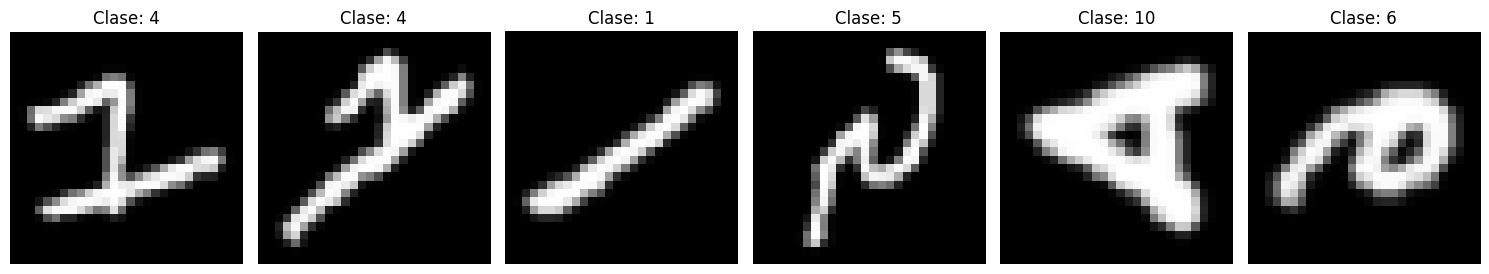

In [4]:
visualize_sample_images(X_images, y_images)

1. b) Dividir el conjunto de datos en tres subconjuntos: Train, Validation y Test.

In [5]:
X_flattened = X_images.reshape(X_images.shape[0], -1)
    
#se reserva el 60% del dataset para entrenamiento, 20% para validacion y 20% para test
X_tv, X_test, y_tv, y_test = split_val_train(
    X_flattened, y_images, test_size=0.2
)

X_train, X_val, y_train, y_val = split_val_train(
    X_tv, y_tv, test_size=0.25
)
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]:,} muestras")
print(f"Tamaño del conjunto de validacion:    {X_val.shape[0]:,} muestras")
print(f"Tamaño del conjunto de test:          {X_test.shape[0]:,} muestras")

Tamaño del conjunto de entrenamiento: 485,733 muestras
Tamaño del conjunto de validacion:    161,911 muestras
Tamaño del conjunto de test:          161,911 muestras


1. c) Normalizar dividiendo todos los valores por 255, de modo que el máximo sea 1.


In [6]:
X_train_norm = X_train / 255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0
#submuestreo el 30% del train
new_size = int(X_train_norm.shape[0] * 0.30) 
X_train_subsampled = X_train_norm[:new_size, :]
y_train = y_train[:new_size] # Reducir y_train al mismo 30%
print(f"Tamaño de entrenamiento reducido al 30%: {X_train_subsampled.shape[0]:,} muestras")
X_train = X_train_subsampled
X_val = X_val_norm
X_test = X_test_norm
X_train_T = X_train.T

Tamaño de entrenamiento reducido al 30%: 145,719 muestras


2. a) Implementar una red neuronal Multi-layer perceptron (MLP) con L capas ocultas, cada
una con M(l) nodos, utilizando ReLU en las capas ocultas y activación softmax en la
capa de salida.


In [7]:
X_train_T = X_train.T
X_val_T = X_val.T

print("Configuracion del modelo M0")
print(f"X_train: {X_train_T.shape} (features x samples)")
print(f"X_val:   {X_val_T.shape} (features x samples)")

N_INPUT = 784
N_OUTPUT = 47
NUM_CLASSES = 47

LAYER_DIMS_M0 = [N_INPUT, 128, 64, N_OUTPUT]

#hiperparametros
EPOCHS_M0 = 100
LEARNING_RATE_M0 = 0.1
full_batch_size = X_train_T.shape[1]

print(f"\nArquitectura del modelo M0:")
print(f"Capa de entrada:  {N_INPUT} neuronas")
print(f"Capa oculta 1: 128 neuronas (ReLU)")
print(f"Capa oculta 2: 64 neuronas (ReLU)")
print(f"Capa de salida: {N_OUTPUT} neuronas (Softmax)")
print(f"\nHiperparametros:")
print(f"Epochs: {EPOCHS_M0}")
print(f"Learning Rate: {LEARNING_RATE_M0}")

Configuracion del modelo M0
X_train: (784, 145719) (features x samples)
X_val:   (784, 161911) (features x samples)

Arquitectura del modelo M0:
Capa de entrada:  784 neuronas
Capa oculta 1: 128 neuronas (ReLU)
Capa oculta 2: 64 neuronas (ReLU)
Capa de salida: 47 neuronas (Softmax)

Hiperparametros:
Epochs: 100
Learning Rate: 0.1


Implementar un algoritmo para entrenar dicha red, mediante backpropagation y gradiente descendente estándar, utilizando como función de costo la cross-entropy.
Entrenar una red neuronal con 2 capas ocultas, con 128 y 64 nodos respectivamente,y graficar la evolución de la función de costo (cross-entropy) sobre los conjuntos de entrenamiento y validación a lo largo de las épocas. Llamaremos a este modelo M0.

In [8]:
#entrenar modelo M0
M0 = MLP_Base(LAYER_DIMS_M0)
train_costs, val_costs = M0.train(
    X_train_T, y_train,
    X_val_T, y_val,
    epochs=EPOCHS_M0,
    learning_rate=LEARNING_RATE_M0,
    batch_size=full_batch_size 
)
print("Entrenamiento completado")

Usando Full Batch Gradient Descent.
Epoch 1/100 | Costo Train: 3.9139 | Costo Val: 3.8381 (LR: 0.100000)
Epoch 10/100 | Costo Train: 3.4939 | Costo Val: 3.4500 (LR: 0.100000)
Epoch 20/100 | Costo Train: 3.0508 | Costo Val: 3.0050 (LR: 0.100000)
Epoch 30/100 | Costo Train: 2.6664 | Costo Val: 2.6301 (LR: 0.100000)
Epoch 40/100 | Costo Train: 2.3806 | Costo Val: 2.3525 (LR: 0.100000)
Epoch 50/100 | Costo Train: 2.1628 | Costo Val: 2.1413 (LR: 0.100000)
Epoch 60/100 | Costo Train: 1.9949 | Costo Val: 1.9787 (LR: 0.100000)
Epoch 70/100 | Costo Train: 1.8625 | Costo Val: 1.8503 (LR: 0.100000)
Epoch 80/100 | Costo Train: 1.7581 | Costo Val: 1.7528 (LR: 0.100000)

--- Early Stopping activado en la Ã‰poca 85 (Paciencia=5) ---
Entrenamiento completado


Reportar las siguientes métricas de performance, sobre los conjuntos de entrenamiento
y validación, para el modelo base entrenado:
Accuracy
Cross-Entropy
Matriz de Confusión
F1-Score Macro


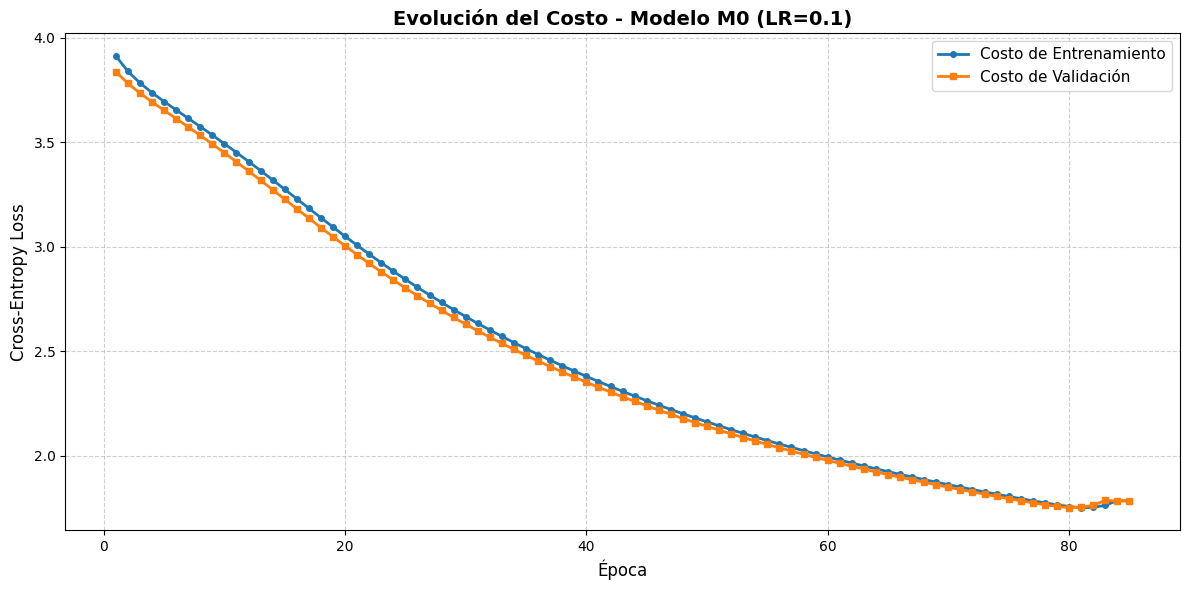

=== Evaluación en Conjunto de Entrenamiento ===


/kaggle/input/metrics-py/metrics.py:32: RuntimeWarning: invalid value encountered in divide
  precision = np.where((TP + FP) != 0, TP / (TP + FP), 0)
/kaggle/input/metrics-py/metrics.py:34: RuntimeWarning: invalid value encountered in divide
  f1_scores = np.where((precision + recall) != 0, 2 * (precision * recall) / (precision + recall), 0)


 MÉTRICAS DE PERFORMANCE - ENTRENAMIENTO
  Accuracy:        0.5501 (55.01%)
  Cross-Entropy:   1.783813
  F1-Score Macro:  0.2995
  Total predicciones correctas: 80158 / 145719


<Figure size 640x480 with 0 Axes>

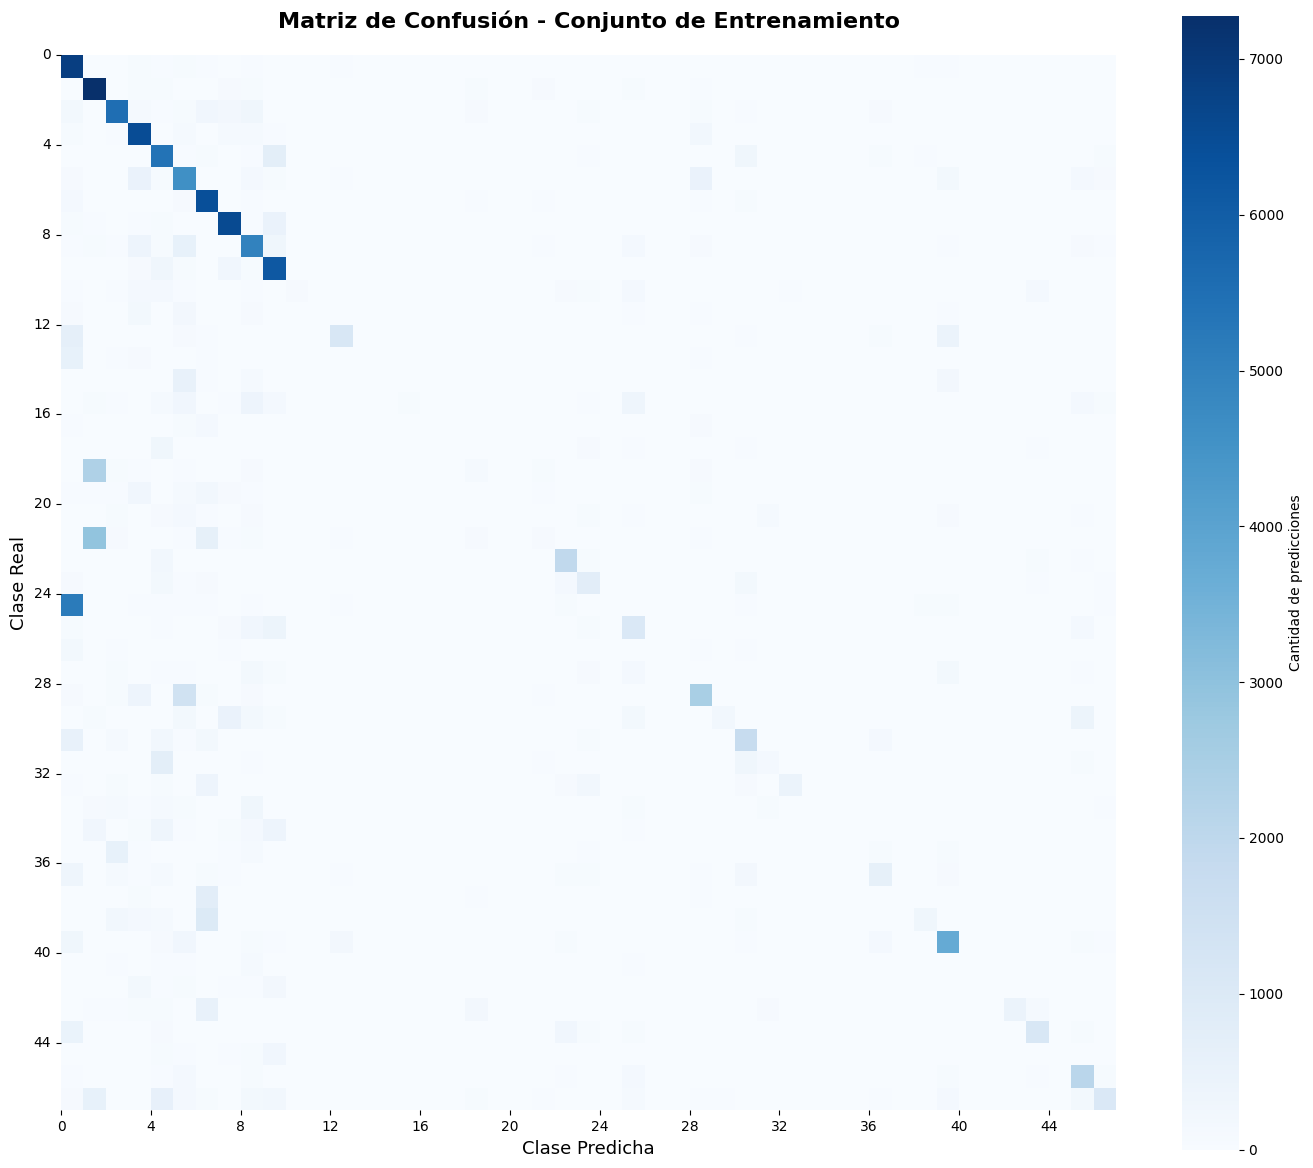


--- Análisis de Errores: Matriz de Confusión - Conjunto de Entrenamiento ---

Top 5 clases con más errores:
  1. Clase 24: 5809/5810 errores (accuracy: 0.0%)
  2. Clase 21: 4098/4200 errores (accuracy: 2.4%)
  3. Clase 18: 2917/3038 errores (accuracy: 4.0%)
  4. Clase 46: 2795/3850 errores (accuracy: 27.4%)
  5. Clase 28: 2403/4896 errores (accuracy: 50.9%)

Top 10 confusiones más frecuentes (Real → Predicho):
  1. Clase 24 → Clase 0: 5173 veces
  2. Clase 21 → Clase 1: 2936 veces
  3. Clase 18 → Clase 1: 2354 veces
  4. Clase 28 → Clase 5: 1449 veces
  5. Clase 38 → Clase 6: 989 veces
  6. Clase 37 → Clase 6: 776 veces
  7. Clase 31 → Clase 4: 754 veces
  8. Clase 4 → Clase 9: 750 veces
  9. Clase 12 → Clase 0: 671 veces
  10. Clase 21 → Clase 6: 635 veces

=== Evaluación en Conjunto de Validación ===


/kaggle/input/metrics-py/metrics.py:32: RuntimeWarning: invalid value encountered in divide
  precision = np.where((TP + FP) != 0, TP / (TP + FP), 0)
/kaggle/input/metrics-py/metrics.py:34: RuntimeWarning: invalid value encountered in divide
  f1_scores = np.where((precision + recall) != 0, 2 * (precision * recall) / (precision + recall), 0)


 MÉTRICAS DE PERFORMANCE - VALIDACIÓN
  Accuracy:        0.5505 (55.05%)
  Cross-Entropy:   1.785155
  F1-Score Macro:  0.2985
  Total predicciones correctas: 89138 / 161911


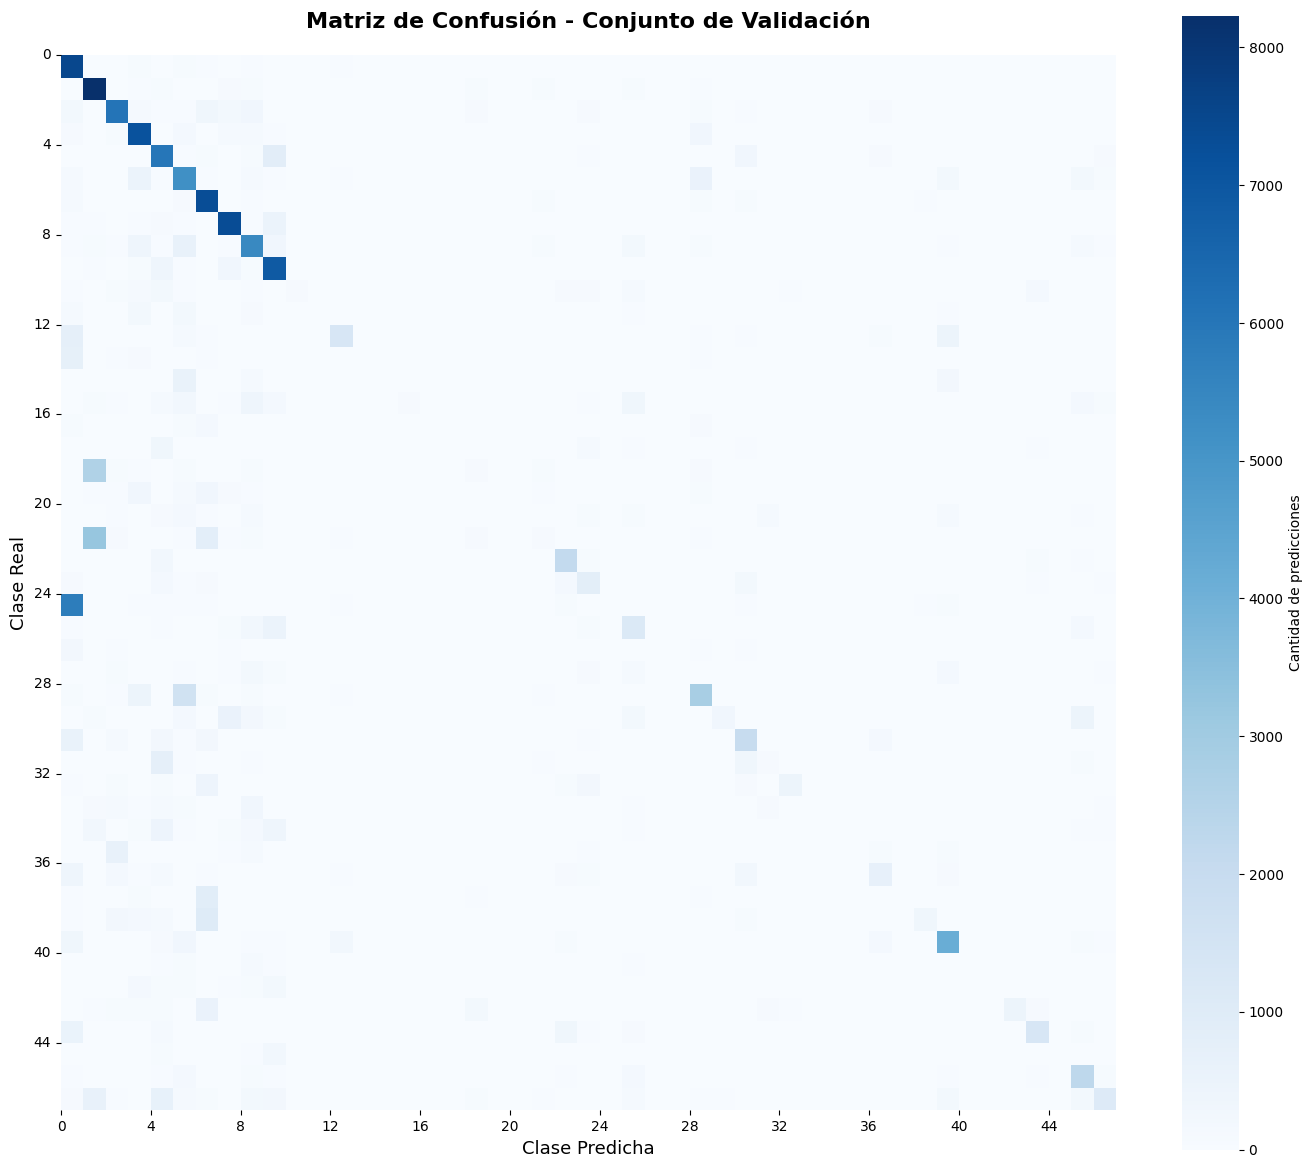


--- Análisis de Errores: Matriz de Confusión - Conjunto de Validación ---

Top 5 clases con más errores:
  1. Clase 24: 6463/6464 errores (accuracy: 0.0%)
  2. Clase 21: 4655/4754 errores (accuracy: 2.1%)
  3. Clase 18: 3227/3353 errores (accuracy: 3.8%)
  4. Clase 46: 3027/4113 errores (accuracy: 26.4%)
  5. Clase 28: 2679/5525 errores (accuracy: 51.5%)

Top 10 confusiones más frecuentes (Real → Predicho):
  1. Clase 24 → Clase 0: 5789 veces
  2. Clase 21 → Clase 1: 3243 veces
  3. Clase 18 → Clase 1: 2628 veces
  4. Clase 28 → Clase 5: 1611 veces
  5. Clase 38 → Clase 6: 1035 veces
  6. Clase 37 → Clase 6: 925 veces
  7. Clase 4 → Clase 9: 899 veces
  8. Clase 21 → Clase 6: 809 veces
  9. Clase 31 → Clase 4: 771 veces
  10. Clase 12 → Clase 0: 740 veces

RESUMEN COMPARATIVO: TRAIN vs VALIDATION

Métrica                Entrenamiento      Validación      Diferencia
--------------------------------------------------------------------------------
Accuracy                      0.5501    

In [9]:
plot_learning_curves(train_costs, val_costs, title="Evolución del Costo - Modelo M0",learning_rate=LEARNING_RATE_M0)
plt.savefig('curvas_aprendizaje_M0.png', dpi=300, bbox_inches='tight')
print("=== Evaluación en Conjunto de Entrenamiento ===")
train_metrics = report_performance(M0, X_train_T, y_train, NUM_CLASSES)
print_metrics(train_metrics, "Entrenamiento")
conf_matrix_train = train_metrics['Confusion Matrix']
plot_confusion_matrix(
    conf_matrix_train, 
    title="Matriz de Confusión - Conjunto de Entrenamiento",
    normalize=False
)

print("\n" + "="*80)
print("=== Evaluación en Conjunto de Validación ===")
val_metrics = report_performance(M0, X_val_T, y_val, NUM_CLASSES)
print_metrics(val_metrics, "Validación")
conf_matrix_val = val_metrics['Confusion Matrix']

plot_confusion_matrix(
    conf_matrix_val, 
    title="Matriz de Confusión - Conjunto de Validación",
    normalize=False
)

compare_train_val_metrics(train_metrics, val_metrics)

Implementar las siguientes mejoras al algoritmo de entrenamiento, y para cada una
reportar el efecto observado sobre el tiempo de entrenamiento y la performance del
modelo resultante.


 Balanced - Experimento 1: Mini-Batch SGD

Descripción: Gradiente descendente estocástico con mini-batches, sin optimizaciones
Arquitectura: [784, 128, 64, 47]

Hiperparámetros:
  batch_size: 128
  optimizer: sgd
  lambda_l2: 0.0
  X_train_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_train: [24  1 46 ...  7 18 18]
  X_val_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_val: [30  1 31 ... 17 24 45]
  NUM_CLASSES: 47
  learning_rate: 0.01
  epochs: 50
Usando Mini-Batch (TamaÃ±o: 128).
Epoch 1/50 | Costo Train: 2.1973 | Costo Val: 1.5114 (LR: 0.010000)
Epoch 10/50 | Costo Train: 0.7264 | Costo Val: 0.7307 (LR: 0.010000)
Epoch 20/50 | Costo Train: 0.5723 | Costo Val: 0.6073 (LR: 0.010000)
Epoch 30/50 | Costo Train: 0.5018 | Costo Val: 0.5391 (LR: 0.010000)
Epoc

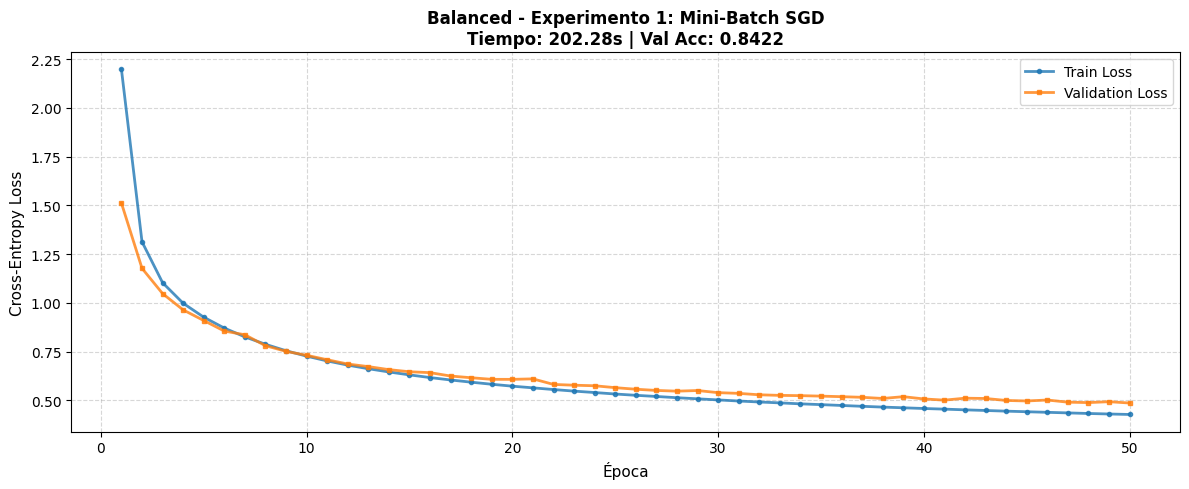

RESULTADOS FINALES:
  Accuracy (Val):     0.8422 (84.22%)
  F1-Score Macro:     0.7869
  Cross-Entropy:      0.485926
  Tiempo:             202.28s (3.37 min)
  Épocas completadas: 50/50
--------------------------------------------------------------------------------


In [10]:
#hiperparametros
EPOCHS_EXP = 50
LR_BASE = 0.01
BATCH_SIZE = 128
PATIENCE = 10
LAMBDA_L2 = 0.0001
LAYER_DIMS_BALANCED = [784, 128, 64, 47]
DATA_KWARGS = {
    'X_train_T': X_train_T, 
    'y_train': y_train, 
    'X_val_T': X_val_T, 
    'y_val': y_val,
    'NUM_CLASSES': NUM_CLASSES,
    'learning_rate': LR_BASE,
    'epochs': EPOCHS_EXP 
}
results_balanced = []
trained_models_balanced = {}

# Experimento 1
M_SGD, m_sgd_metrics, m_sgd_time, m_sgd_epochs = run_experiment(
    "Balanced - Experimento 1: Mini-Batch SGD",
    LAYER_DIMS_BALANCED,
    description="Gradiente descendente estocástico con mini-batches, sin optimizaciones",
    save_key='Balanced_SGD',
    batch_size=BATCH_SIZE,
    optimizer='sgd',
    lambda_l2=0.0,
    **DATA_KWARGS
)
model_key = 'Balanced_MiniBatchSGD'
trained_models_balanced[model_key] = M_SGD
results_balanced.append({
    'Arquitectura': 'Balanced',
    'Layer_Dims': str(LAYER_DIMS_BALANCED),
    'Modelo': 'Mini-Batch SGD',
    'Model_Key': model_key,
    'Optimizer': 'sgd',
    'LR_Schedule': None,
    'Lambda_L2': 0.0,
    'Batch_Size': BATCH_SIZE,
    'Learning_Rate': LR_BASE,
    'Patience': EPOCHS_EXP,
    **m_sgd_metrics,
    'Tiempo (s)': m_sgd_time,
    'Épocas': m_sgd_epochs
})

 Balanced - Experimento 2: Optimizador Adam

Descripción: Optimizador Adam con momentos adaptativos (beta1=0.9, beta2=0.999)
Arquitectura: [784, 128, 64, 47]

Hiperparámetros:
  batch_size: 128
  optimizer: adam
  lambda_l2: 0.0
  X_train_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_train: [24  1 46 ...  7 18 18]
  X_val_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_val: [30  1 31 ... 17 24 45]
  NUM_CLASSES: 47
  learning_rate: 0.01
  epochs: 50
Usando Mini-Batch (TamaÃ±o: 128).
Epoch 1/50 | Costo Train: 0.8725 | Costo Val: 0.7043 (LR: 0.010000)
Epoch 10/50 | Costo Train: 0.5634 | Costo Val: 0.6498 (LR: 0.010000)

--- Early Stopping activado en la Ã‰poca 13 (Paciencia=5) ---
Evaluando performance...


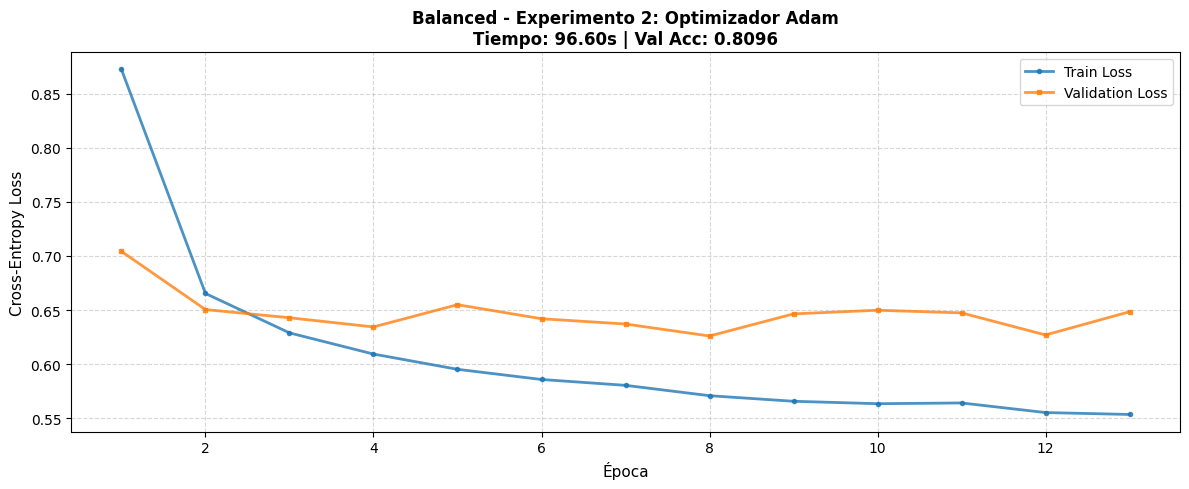

RESULTADOS FINALES:
  Accuracy (Val):     0.8096 (80.96%)
  F1-Score Macro:     0.7300
  Cross-Entropy:      0.648445
  Tiempo:             96.60s (1.61 min)
  Épocas completadas: 13/50
--------------------------------------------------------------------------------


In [11]:
# Experimento 2
M_Adam, m_adam_metrics, m_adam_time, m_adam_epochs = run_experiment(
    "Balanced - Experimento 2: Optimizador Adam",
    LAYER_DIMS_BALANCED,
    description="Optimizador Adam con momentos adaptativos (beta1=0.9, beta2=0.999)",
    save_key='Balanced_Adam',
    batch_size=BATCH_SIZE,
    optimizer='adam',
    lambda_l2=0.0,
    **DATA_KWARGS
)
model_key = 'Balanced_Adam'
trained_models_balanced[model_key] = M_Adam
results_balanced.append({
    'Arquitectura': 'Balanced',
    'Layer_Dims': str(LAYER_DIMS_BALANCED),
    'Modelo': 'Adam',
    'Model_Key': model_key,
    'Optimizer': 'adam',
    'LR_Schedule': None,
    'Lambda_L2': 0.0,
    'Batch_Size': BATCH_SIZE,
    'Learning_Rate': LR_BASE,
    'Patience': EPOCHS_EXP,
    **m_adam_metrics,
    'Tiempo (s)': m_adam_time,
    'Épocas': m_adam_epochs
})

 Balanced - Experimento 3a: Adam + Rate Scheduling Lineal

Descripción: Adam con decaimiento lineal de learning rate (saturación al 10%)
Arquitectura: [784, 128, 64, 47]

Hiperparámetros:
  batch_size: 128
  optimizer: adam
  lr_schedule: linear_schedule
  min_lr_factor: 0.1
  X_train_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_train: [24  1 46 ...  7 18 18]
  X_val_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_val: [30  1 31 ... 17 24 45]
  NUM_CLASSES: 47
  learning_rate: 0.01
  epochs: 50
Usando Mini-Batch (TamaÃ±o: 128).
Epoch 1/50 | Costo Train: 0.8486 | Costo Val: 0.7203 (LR: 0.009820)
Epoch 10/50 | Costo Train: 0.5183 | Costo Val: 0.6092 (LR: 0.008200)
Epoch 20/50 | Costo Train: 0.4458 | Costo Val: 0.6011 (LR: 0.006400)

--- Early Stopping activad

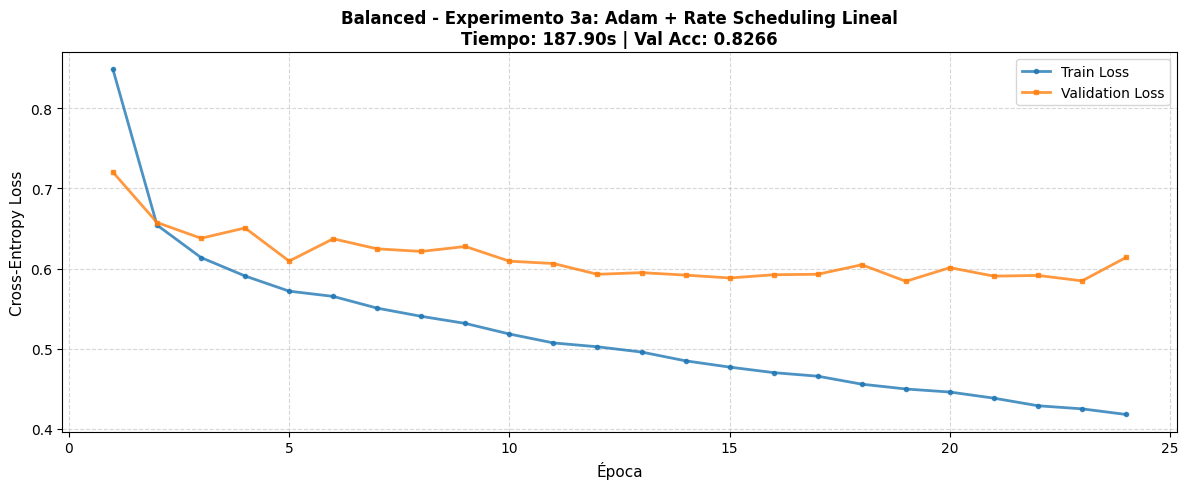

RESULTADOS FINALES:
  Accuracy (Val):     0.8266 (82.66%)
  F1-Score Macro:     0.7579
  Cross-Entropy:      0.613872
  Tiempo:             187.90s (3.13 min)
  Épocas completadas: 24/50
--------------------------------------------------------------------------------


In [12]:
# EXPERIMENTO 3a: 
M_Linear, m_linear_metrics, m_linear_time, m_linear_epochs = run_experiment(
    "Balanced - Experimento 3a: Adam + Rate Scheduling Lineal",
    LAYER_DIMS_BALANCED,
    description="Adam con decaimiento lineal de learning rate (saturación al 10%)",
    save_key='Balanced_Linear',
    batch_size=BATCH_SIZE,
    optimizer='adam',
    lr_schedule=linear_schedule,
    min_lr_factor=0.1,
    **DATA_KWARGS
)
model_key = 'Balanced_RateSchedulingLineal'
trained_models_balanced[model_key] = M_Linear
results_balanced.append({
    'Arquitectura': 'Balanced',
    'Layer_Dims': str(LAYER_DIMS_BALANCED),
    'Modelo': 'Rate Scheduling Lineal',
    'Model_Key': model_key,
    'Optimizer': 'adam',
    'LR_Schedule': 'linear',
    'Lambda_L2': 0.0,
    'Batch_Size': BATCH_SIZE,
    'Learning_Rate': LR_BASE,
    'Patience': EPOCHS_EXP,
    **m_linear_metrics,
    'Tiempo (s)': m_linear_time,
    'Épocas': m_linear_epochs
})

 Balanced - Experimento 3b: Adam + Rate Scheduling Exponencial

Descripción: Adam con decaimiento exponencial de learning rate (decay=0.97)
Arquitectura: [784, 128, 64, 47]

Hiperparámetros:
  batch_size: 128
  optimizer: adam
  lr_schedule: exponential_schedule
  decay_rate: 0.97
  X_train_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_train: [24  1 46 ...  7 18 18]
  X_val_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_val: [30  1 31 ... 17 24 45]
  NUM_CLASSES: 47
  learning_rate: 0.01
  epochs: 50
Usando Mini-Batch (TamaÃ±o: 128).
Epoch 1/50 | Costo Train: 0.8480 | Costo Val: 0.7257 (LR: 0.009700)
Epoch 10/50 | Costo Train: 0.5012 | Costo Val: 0.5871 (LR: 0.007374)

--- Early Stopping activado en la Ã‰poca 20 (Paciencia=5) ---
Evaluando performance...


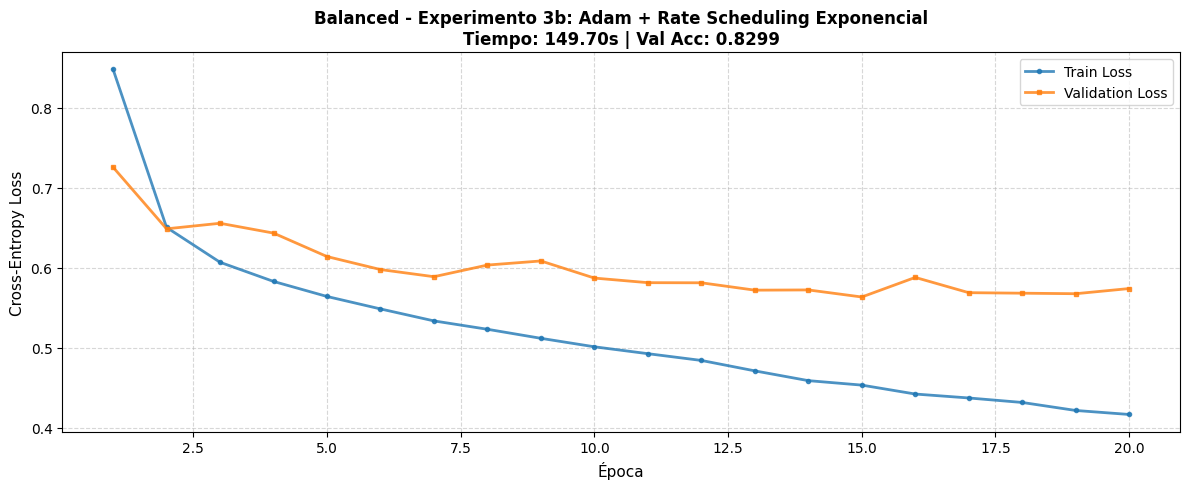

RESULTADOS FINALES:
  Accuracy (Val):     0.8299 (82.99%)
  F1-Score Macro:     0.7680
  Cross-Entropy:      0.574008
  Tiempo:             149.70s (2.50 min)
  Épocas completadas: 20/50
--------------------------------------------------------------------------------


In [13]:
# EXPERIMENTO 3b:
M_Exp, m_exp_metrics, m_exp_time, m_exp_epochs = run_experiment(
    "Balanced - Experimento 3b: Adam + Rate Scheduling Exponencial",
    LAYER_DIMS_BALANCED,
    description="Adam con decaimiento exponencial de learning rate (decay=0.97)",
    save_key='Balanced_Exponential',
    batch_size=BATCH_SIZE,
    optimizer='adam',
    lr_schedule=exponential_schedule,
    decay_rate=0.97,
    **DATA_KWARGS
)
model_key = 'Balanced_RateSchedulingExponencial'
trained_models_balanced[model_key] = M_Exp
results_balanced.append({
    'Arquitectura': 'Balanced',
    'Layer_Dims': str(LAYER_DIMS_BALANCED),
    'Modelo': 'Rate Scheduling Exponencial',
    'Model_Key': model_key,
    'Optimizer': 'adam',
    'LR_Schedule': 'exponential',
    'Lambda_L2': 0.0,
    'Batch_Size': BATCH_SIZE,
    'Learning_Rate': LR_BASE,
    'Patience': EPOCHS_EXP,
    **m_exp_metrics,
    'Tiempo (s)': m_exp_time,
    'Épocas': m_exp_epochs
})

 Balanced - Experimento 4: Regularización L2 + Early Stopping

Descripción: Adam con penalización L2 (lambda=0.0001) y detención temprana (paciencia=10)
Arquitectura: [784, 128, 64, 47]

Hiperparámetros:
  batch_size: 128
  optimizer: adam
  lambda_l2: 0.0001
  patience: 10
  X_train_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_train: [24  1 46 ...  7 18 18]
  X_val_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_val: [30  1 31 ... 17 24 45]
  NUM_CLASSES: 47
  learning_rate: 0.01
  epochs: 50
Usando Mini-Batch (TamaÃ±o: 128).
Epoch 1/50 | Costo Train: 0.8857 | Costo Val: 0.7171 (LR: 0.010000)
Epoch 10/50 | Costo Train: 0.6009 | Costo Val: 0.6496 (LR: 0.010000)
Epoch 20/50 | Costo Train: 0.5799 | Costo Val: 0.6413 (LR: 0.010000)

--- Early Stopping activado

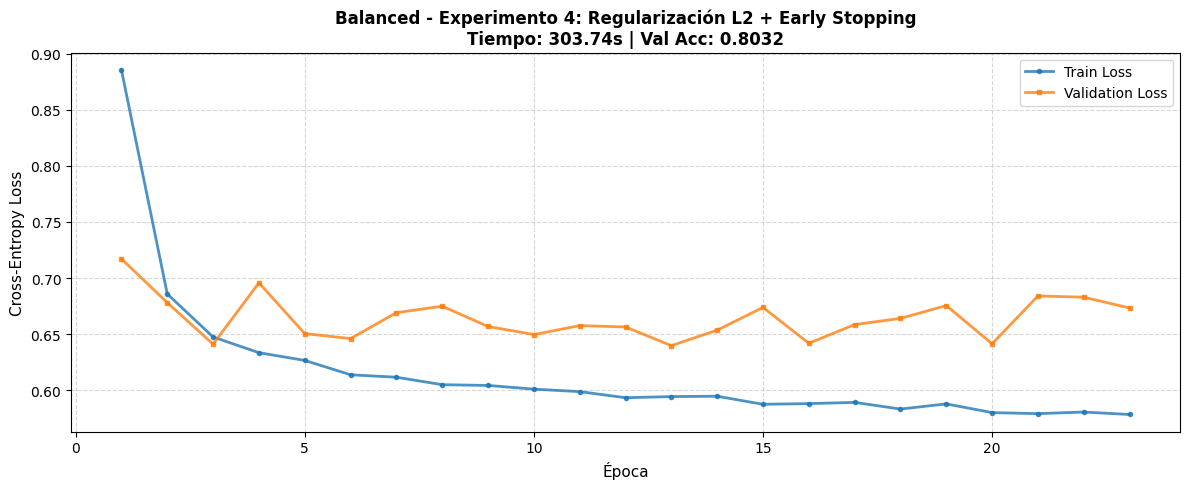

RESULTADOS FINALES:
  Accuracy (Val):     0.8032 (80.32%)
  F1-Score Macro:     0.7211
  Cross-Entropy:      0.673261
  Tiempo:             303.74s (5.06 min)
  Épocas completadas: 23/50
--------------------------------------------------------------------------------
Resumen experimentos: arquitectura balanced
                        Modelo  Accuracy  Cross-Entropy  F1-Score Macro  \
0               Mini-Batch SGD  0.842222       0.485926        0.786928   
1                         Adam  0.809618       0.648445        0.729953   
2       Rate Scheduling Lineal  0.826565       0.613872        0.757863   
3  Rate Scheduling Exponencial  0.829894       0.574008        0.767979   
4               Regularización  0.803182       0.673261        0.721051   

   Tiempo (s)  Épocas  
0  202.282110      50  
1   96.601873      13  
2  187.898664      24  
3  149.703000      20  
4  303.742765      23  


In [14]:
# Experimento 4: 
M_Reg, m_reg_metrics, m_reg_time, m_reg_epochs = run_experiment(
    "Balanced - Experimento 4: Regularización L2 + Early Stopping",
    LAYER_DIMS_BALANCED,
    description=f"Adam con penalización L2 (lambda={LAMBDA_L2}) y detención temprana (paciencia={PATIENCE})",
    save_key='Balanced_Reg',
    batch_size=BATCH_SIZE,
    optimizer='adam',
    lambda_l2=LAMBDA_L2,
    patience=PATIENCE,
    **DATA_KWARGS
)
model_key = 'Balanced_Regularizacion'
trained_models_balanced[model_key] = M_Reg
results_balanced.append({
    'Arquitectura': 'Balanced',
    'Layer_Dims': str(LAYER_DIMS_BALANCED),
    'Modelo': 'Regularización',
    'Model_Key': model_key,
    'Optimizer': 'adam',
    'LR_Schedule': None,
    'Lambda_L2': LAMBDA_L2,
    'Batch_Size': BATCH_SIZE,
    'Learning_Rate': LR_BASE,
    'Patience': PATIENCE,
    **m_reg_metrics, 
    'Tiempo (s)': m_reg_time,
    'Épocas': m_reg_epochs
})

results_df_balanced = pd.DataFrame(results_balanced)

print("Resumen experimentos: arquitectura balanced")
print(results_df_balanced[['Modelo', 'Accuracy', 'Cross-Entropy', 'F1-Score Macro', 'Tiempo (s)', 'Épocas']])

Explorar cambios en la arquitectura de la red (es decir, la cantidad de capas ocultas
y unidades ocultas por capa), y en los hiperparámetros (cada uno de los ítems en la
lista anterior tiene parámetros que se pueden variar), y determinar la configuración
que funcione mejor (menor error de validación). Llamaremos a este modelo M1.



Configuración para experimentos:
  Épocas:              50
  Learning Rate base:  0.005
  Batch Size:          64
  Patience:            15
  Lambda L2:           0.0005

  Arquitecturas NUEVAS:
    A) Wide (Pocas capas, muchas neuronas):  [784, 256, 47]
    C) Deep (Muchas capas, pocas neuronas):  [784, 96, 64, 48, 32, 47]

ARQUITECTURA: Wide - [784, 256, 47]
 R2-Wide - Experimento 1: Mini-Batch SGD

Descripción: SGD con arquitectura Wide
Arquitectura: [784, 256, 47]

Hiperparámetros:
  batch_size: 64
  optimizer: sgd
  lambda_l2: 0.0
  X_train_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_train: [24  1 46 ...  7 18 18]
  X_val_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_val: [30  1 31 ... 17 24 45]
  NUM_CLASSES: 47
  learning_rate: 0.005
  epochs: 50

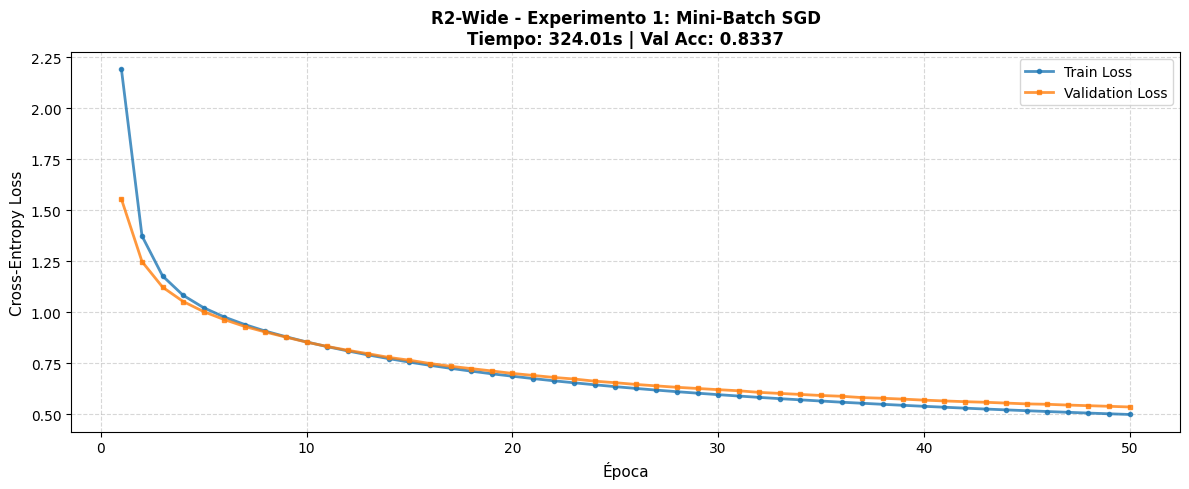

RESULTADOS FINALES:
  Accuracy (Val):     0.8337 (83.37%)
  F1-Score Macro:     0.7689
  Cross-Entropy:      0.535878
  Tiempo:             324.01s (5.40 min)
  Épocas completadas: 50/50
--------------------------------------------------------------------------------
 R2-Wide - Experimento 2: Optimizador Adam

Descripción: Adam con arquitectura Wide
Arquitectura: [784, 256, 47]

Hiperparámetros:
  batch_size: 64
  optimizer: adam
  lambda_l2: 0.0
  X_train_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_train: [24  1 46 ...  7 18 18]
  X_val_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_val: [30  1 31 ... 17 24 45]
  NUM_CLASSES: 47
  learning_rate: 0.005
  epochs: 50
Usando Mini-Batch (TamaÃ±o: 64).
Epoch 1/50 | Costo Train: 0.7275 | Costo Val: 0.5752 (LR: 

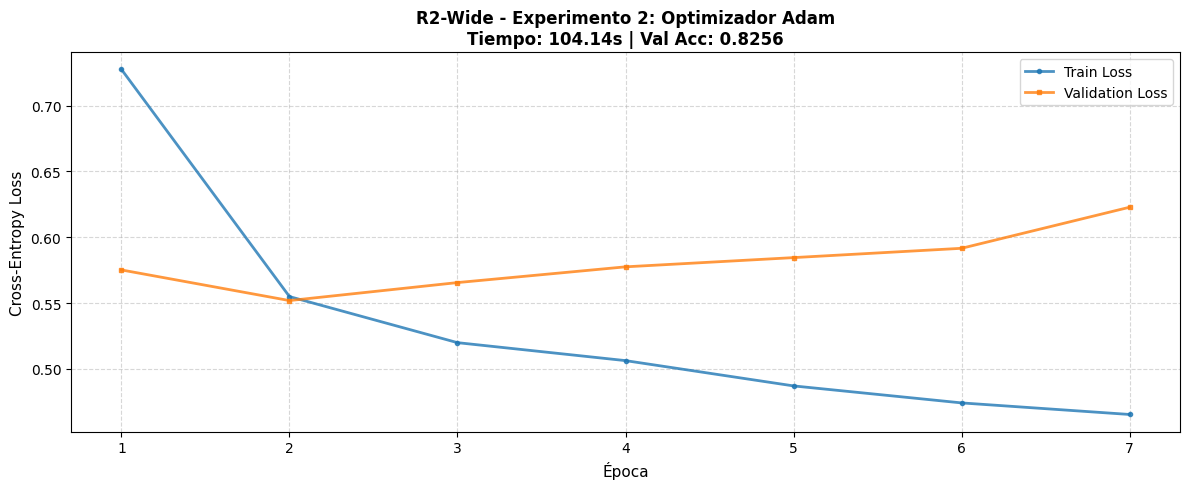

RESULTADOS FINALES:
  Accuracy (Val):     0.8256 (82.56%)
  F1-Score Macro:     0.7608
  Cross-Entropy:      0.622813
  Tiempo:             104.14s (1.74 min)
  Épocas completadas: 7/50
--------------------------------------------------------------------------------
 R2-Wide - Experimento 3a: Adam + Rate Scheduling Lineal

Descripción: Adam con decaimiento lineal y arquitectura Wide
Arquitectura: [784, 256, 47]

Hiperparámetros:
  batch_size: 64
  optimizer: adam
  lr_schedule: linear_schedule
  min_lr_factor: 0.1
  X_train_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_train: [24  1 46 ...  7 18 18]
  X_val_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_val: [30  1 31 ... 17 24 45]
  NUM_CLASSES: 47
  learning_rate: 0.005
  epochs: 50
Usando Mini-Batch (Tam

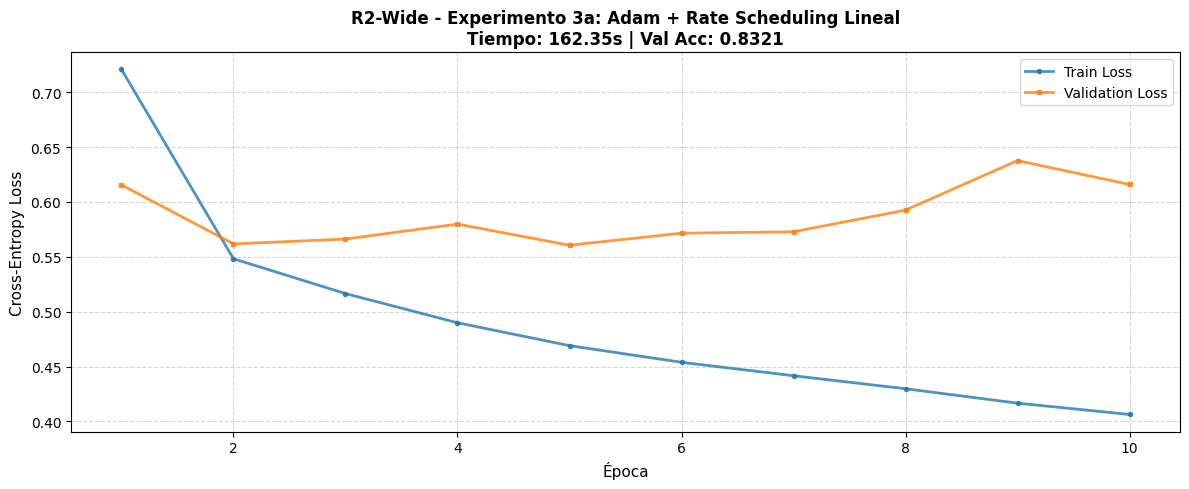

RESULTADOS FINALES:
  Accuracy (Val):     0.8321 (83.21%)
  F1-Score Macro:     0.7734
  Cross-Entropy:      0.615868
  Tiempo:             162.35s (2.71 min)
  Épocas completadas: 10/50
--------------------------------------------------------------------------------
 R2-Wide - Experimento 3b: Adam + Rate Scheduling Exponencial

Descripción: Adam con decaimiento exponencial (decay=0.95) y arquitectura Wide
Arquitectura: [784, 256, 47]

Hiperparámetros:
  batch_size: 64
  optimizer: adam
  lr_schedule: exponential_schedule
  decay_rate: 0.95
  X_train_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_train: [24  1 46 ...  7 18 18]
  X_val_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_val: [30  1 31 ... 17 24 45]
  NUM_CLASSES: 47
  learning_rate: 0.005
  epochs

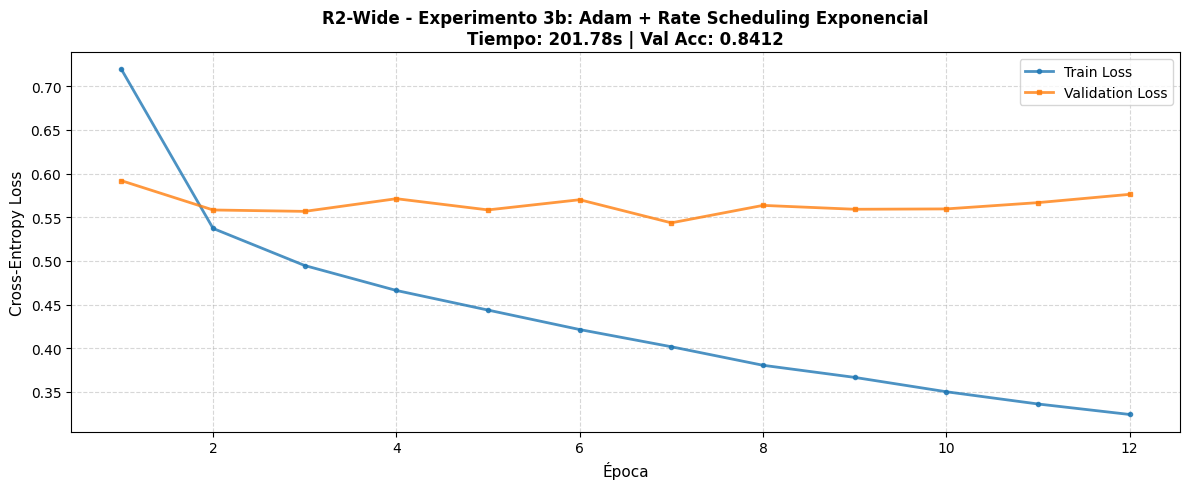

RESULTADOS FINALES:
  Accuracy (Val):     0.8412 (84.12%)
  F1-Score Macro:     0.7920
  Cross-Entropy:      0.576266
  Tiempo:             201.78s (3.36 min)
  Épocas completadas: 12/50
--------------------------------------------------------------------------------
 R2-Wide - Experimento 5: Regularización L2 + Early Stopping

Descripción: Adam con L2 (lambda=0.0005) y early stopping (paciencia=15) en Wide
Arquitectura: [784, 256, 47]

Hiperparámetros:
  batch_size: 64
  optimizer: adam
  lambda_l2: 0.0005
  patience: 15
  X_train_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_train: [24  1 46 ...  7 18 18]
  X_val_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_val: [30  1 31 ... 17 24 45]
  NUM_CLASSES: 47
  learning_rate: 0.005
  epochs: 50
Usando Mini-Ba

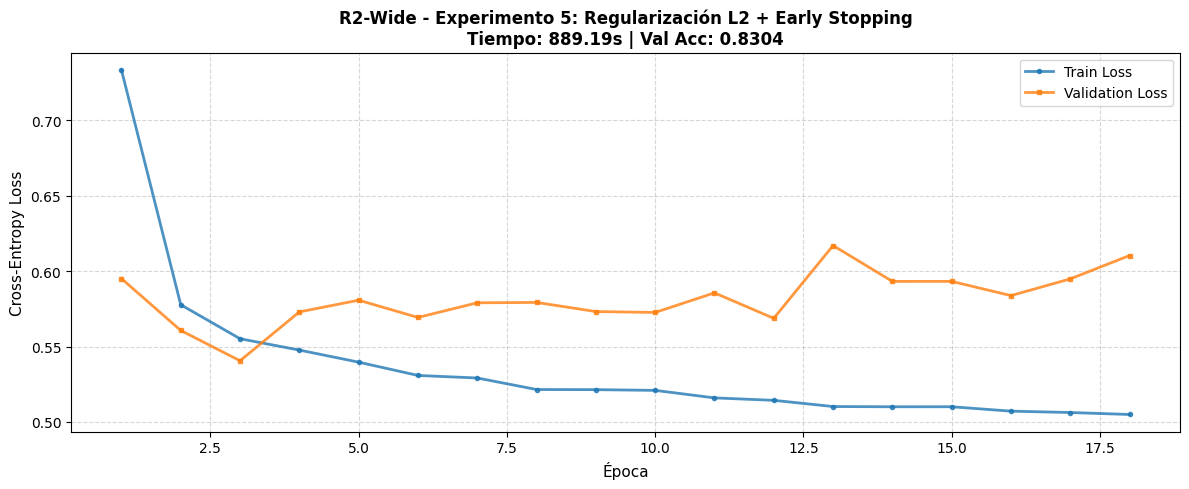

RESULTADOS FINALES:
  Accuracy (Val):     0.8304 (83.04%)
  F1-Score Macro:     0.7639
  Cross-Entropy:      0.610302
  Tiempo:             889.19s (14.82 min)
  Épocas completadas: 18/50
--------------------------------------------------------------------------------

ARQUITECTURA: Deep - [784, 96, 64, 48, 32, 47]
 R2-Deep - Experimento 1: Mini-Batch SGD

Descripción: SGD con arquitectura Deep
Arquitectura: [784, 96, 64, 48, 32, 47]

Hiperparámetros:
  batch_size: 64
  optimizer: sgd
  lambda_l2: 0.0
  X_train_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_train: [24  1 46 ...  7 18 18]
  X_val_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_val: [30  1 31 ... 17 24 45]
  NUM_CLASSES: 47
  learning_rate: 0.005
  epochs: 50
Usando Mini-Batch (TamaÃ±o: 64).
Ep

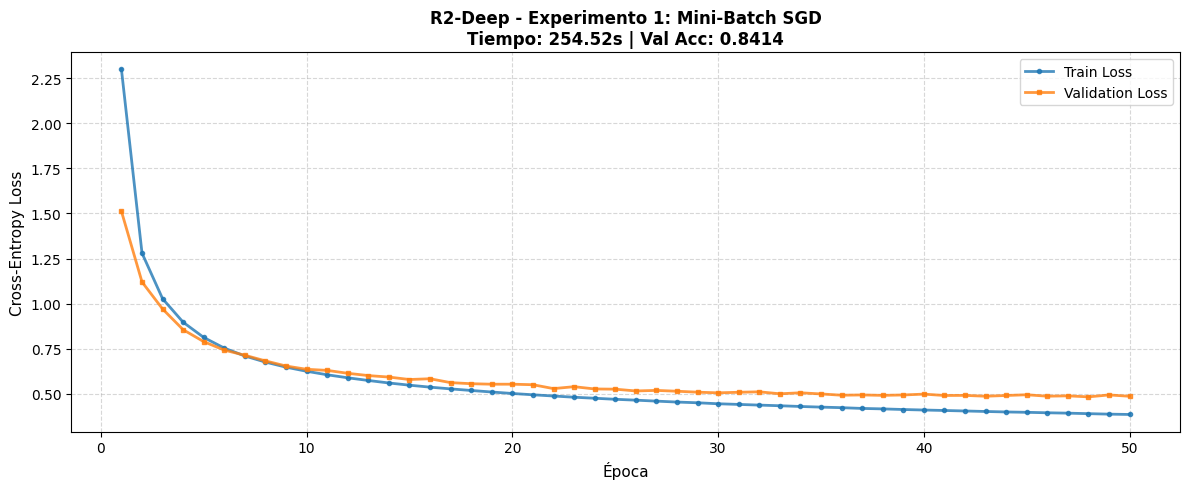

RESULTADOS FINALES:
  Accuracy (Val):     0.8414 (84.14%)
  F1-Score Macro:     0.7848
  Cross-Entropy:      0.486332
  Tiempo:             254.52s (4.24 min)
  Épocas completadas: 50/50
--------------------------------------------------------------------------------
 R2-Deep - Experimento 2: Optimizador Adam

Descripción: Adam con arquitectura Deep
Arquitectura: [784, 96, 64, 48, 32, 47]

Hiperparámetros:
  batch_size: 64
  optimizer: adam
  lambda_l2: 0.0
  X_train_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_train: [24  1 46 ...  7 18 18]
  X_val_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_val: [30  1 31 ... 17 24 45]
  NUM_CLASSES: 47
  learning_rate: 0.005
  epochs: 50
Usando Mini-Batch (TamaÃ±o: 64).
Epoch 1/50 | Costo Train: 0.9596 | Costo Val: 0

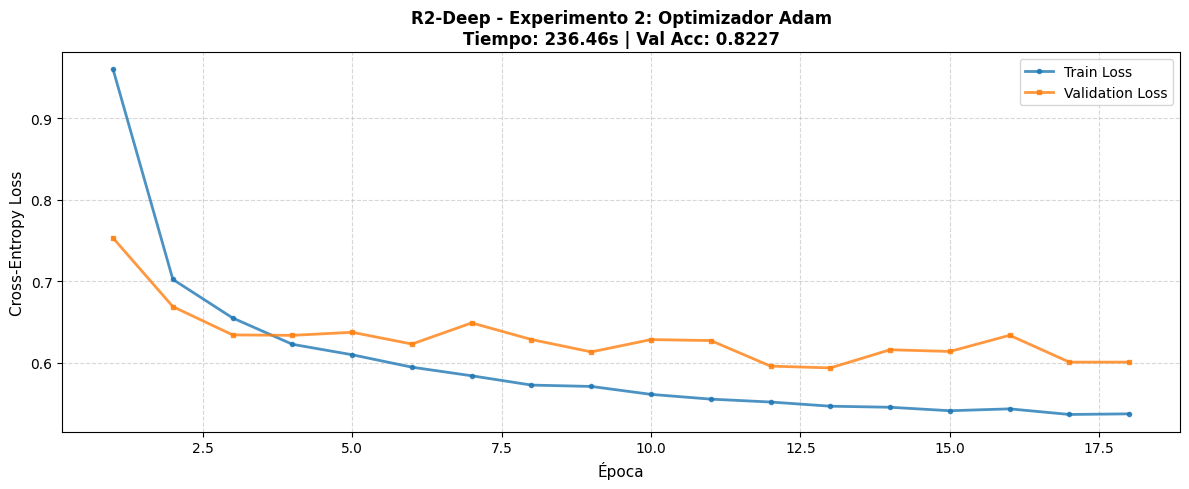

RESULTADOS FINALES:
  Accuracy (Val):     0.8227 (82.27%)
  F1-Score Macro:     0.7555
  Cross-Entropy:      0.600815
  Tiempo:             236.46s (3.94 min)
  Épocas completadas: 18/50
--------------------------------------------------------------------------------
 R2-Deep - Experimento 3a: Adam + Rate Scheduling Lineal

Descripción: Adam con decaimiento lineal y arquitectura Deep
Arquitectura: [784, 96, 64, 48, 32, 47]

Hiperparámetros:
  batch_size: 64
  optimizer: adam
  lr_schedule: linear_schedule
  min_lr_factor: 0.1
  X_train_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_train: [24  1 46 ...  7 18 18]
  X_val_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_val: [30  1 31 ... 17 24 45]
  NUM_CLASSES: 47
  learning_rate: 0.005
  epochs: 50
Usando Min

/kaggle/input/metrics-py/metrics.py:34: RuntimeWarning: invalid value encountered in divide
  f1_scores = np.where((precision + recall) != 0, 2 * (precision * recall) / (precision + recall), 0)


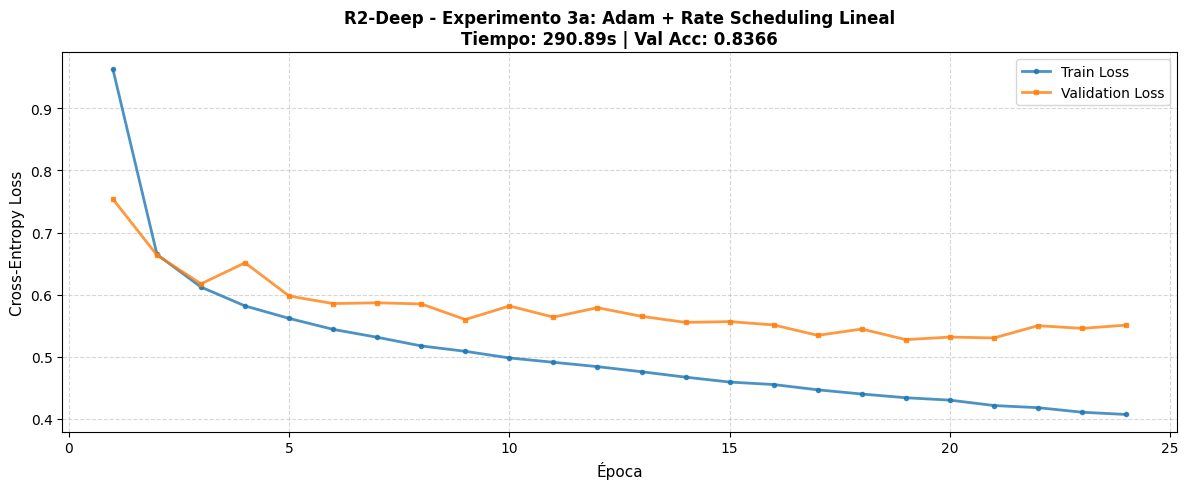

RESULTADOS FINALES:
  Accuracy (Val):     0.8366 (83.66%)
  F1-Score Macro:     0.7688
  Cross-Entropy:      0.550983
  Tiempo:             290.89s (4.85 min)
  Épocas completadas: 24/50
--------------------------------------------------------------------------------
 R2-Deep - Experimento 3b: Adam + Rate Scheduling Exponencial

Descripción: Adam con decaimiento exponencial (decay=0.95) y arquitectura Deep
Arquitectura: [784, 96, 64, 48, 32, 47]

Hiperparámetros:
  batch_size: 64
  optimizer: adam
  lr_schedule: exponential_schedule
  decay_rate: 0.95
  X_train_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_train: [24  1 46 ...  7 18 18]
  X_val_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_val: [30  1 31 ... 17 24 45]
  NUM_CLASSES: 47
  learning_rate: 0.0

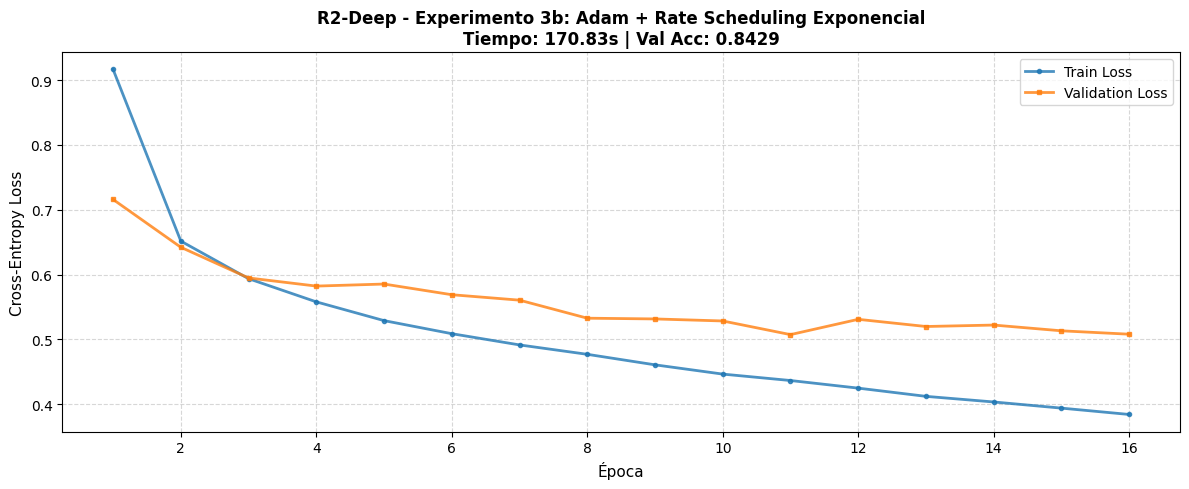

RESULTADOS FINALES:
  Accuracy (Val):     0.8429 (84.29%)
  F1-Score Macro:     0.7879
  Cross-Entropy:      0.508134
  Tiempo:             170.83s (2.85 min)
  Épocas completadas: 16/50
--------------------------------------------------------------------------------
 R2-Deep - Experimento 5: Regularización L2 + Early Stopping

Descripción: Adam con L2 (lambda=0.0005) y early stopping (paciencia=15) en Deep
Arquitectura: [784, 96, 64, 48, 32, 47]

Hiperparámetros:
  batch_size: 64
  optimizer: adam
  lambda_l2: 0.0005
  patience: 15
  X_train_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_train: [24  1 46 ...  7 18 18]
  X_val_T: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  y_val: [30  1 31 ... 17 24 45]
  NUM_CLASSES: 47
  learning_rate: 0.005
  epochs: 50
Usa

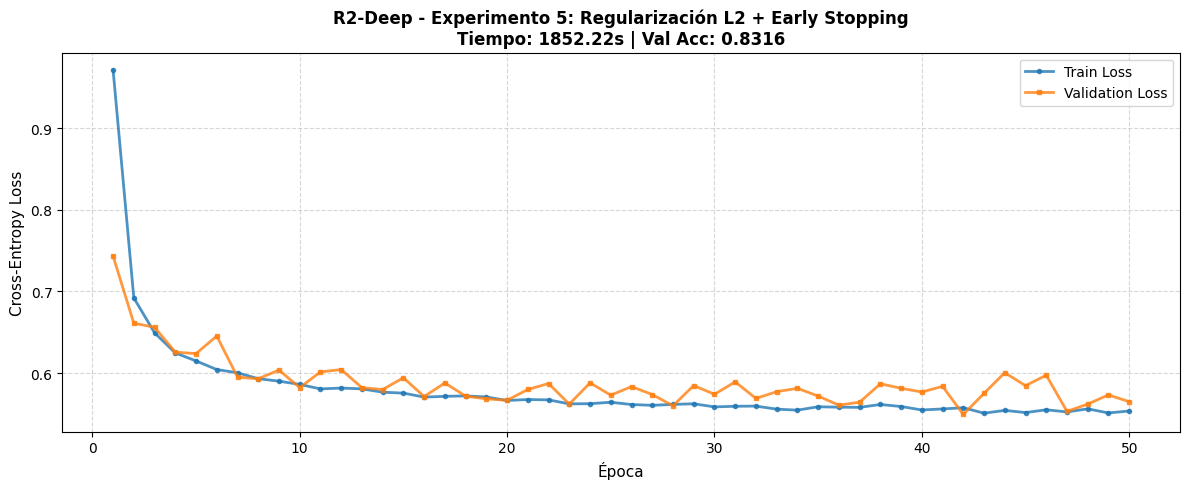

RESULTADOS FINALES:
  Accuracy (Val):     0.8316 (83.16%)
  F1-Score Macro:     0.7680
  Cross-Entropy:      0.564879
  Tiempo:             1852.22s (30.87 min)
  Épocas completadas: 50/50
--------------------------------------------------------------------------------
Resumen de resultados: arquitecturas nuevas
  Arquitectura                       Modelo  Accuracy  Cross-Entropy  \
0         Wide               Mini-Batch SGD  0.833736       0.535878   
1         Wide                         Adam  0.825645       0.622813   
2         Wide       Rate Scheduling Lineal  0.832093       0.615868   
3         Wide  Rate Scheduling Exponencial  0.841209       0.576266   
4         Wide               Regularización  0.830438       0.610302   
5         Deep               Mini-Batch SGD  0.841425       0.486332   
6         Deep                         Adam  0.822724       0.600815   
7         Deep       Rate Scheduling Lineal  0.836583       0.550983   
8         Deep  Rate Scheduling Expone

In [15]:
EPOCHS_EXP_R2 = 50
LR_BASE_R2 = 0.005
BATCH_SIZE_R2 = 64
PATIENCE_R2 = 15
LAMBDA_L2_R2 = 0.0005
EXP_DECAY_RATE_R2 = 0.95

#segunda arquitectura a probar
LAYER_DIMS_WIDE = [784, 256, 47]
#tercera arquitectura
LAYER_DIMS_DEEP = [784, 96, 64, 48, 32, 47]

ARCHITECTURES_NEW = {
    'Wide': LAYER_DIMS_WIDE,
    'Deep': LAYER_DIMS_DEEP
}

DATA_KWARGS['learning_rate'] = LR_BASE_R2
DATA_KWARGS['epochs'] = EPOCHS_EXP_R2

print(f"\nConfiguración para experimentos:")
print(f"  Épocas:              {EPOCHS_EXP_R2}")
print(f"  Learning Rate base:  {LR_BASE_R2}")
print(f"  Batch Size:          {BATCH_SIZE_R2}")
print(f"  Patience:            {PATIENCE_R2}")
print(f"  Lambda L2:           {LAMBDA_L2_R2}")

print(f"\n  Arquitecturas NUEVAS:")
print(f"    A) Wide (Pocas capas, muchas neuronas):  {LAYER_DIMS_WIDE}")
print(f"    C) Deep (Muchas capas, pocas neuronas):  {LAYER_DIMS_DEEP}")

results_new_archs = []
trained_models_new = {}

for arch_name, layer_dims in ARCHITECTURES_NEW.items():
    print("\n" + "="*80)
    print(f"ARQUITECTURA: {arch_name} - {layer_dims}")
    print("="*80)
    
    #experimento 1
    M_temp, m_metrics, m_time, m_epochs = run_experiment(
        f"R2-{arch_name} - Experimento 1: Mini-Batch SGD",
        layer_dims,
        description=f"SGD con arquitectura {arch_name}",
        save_key=f'{arch_name}_SGD_R2',
        batch_size=BATCH_SIZE_R2,
        optimizer='sgd',
        lambda_l2=0.0,
        **DATA_KWARGS
    )
    model_key = f'{arch_name}_MiniBatchSGD'
    trained_models_new[model_key] = M_temp
    results_new_archs.append({
        'Arquitectura': arch_name,
        'Layer_Dims': str(layer_dims),
        'Modelo': 'Mini-Batch SGD',
        'Model_Key': model_key,
        'Optimizer': 'sgd',
        'LR_Schedule': None,
        'Lambda_L2': 0.0,
        'Batch_Size': BATCH_SIZE_R2,
        'Learning_Rate': LR_BASE_R2,
        'Patience': EPOCHS_EXP_R2,
        **m_metrics,
        'Tiempo (s)': m_time,
        'Épocas': m_epochs
    })
    
    #experimento 2
    M_temp, m_metrics, m_time, m_epochs = run_experiment(
        f"R2-{arch_name} - Experimento 2: Optimizador Adam",
        layer_dims,
        description=f"Adam con arquitectura {arch_name}",
        save_key=f'{arch_name}_Adam_R2',
        batch_size=BATCH_SIZE_R2,
        optimizer='adam',
        lambda_l2=0.0,
        **DATA_KWARGS
    )
    model_key = f'{arch_name}_Adam'
    trained_models_new[model_key] = M_temp
    results_new_archs.append({
        'Arquitectura': arch_name,
        'Layer_Dims': str(layer_dims),
        'Modelo': 'Adam',
        'Model_Key': model_key,
        'Optimizer': 'adam',
        'LR_Schedule': None,
        'Lambda_L2': 0.0,
        'Batch_Size': BATCH_SIZE_R2,
        'Learning_Rate': LR_BASE_R2,
        'Patience': EPOCHS_EXP_R2,
        **m_metrics,
        'Tiempo (s)': m_time,
        'Épocas': m_epochs
    })
    
    #experimento 3a
    M_temp, m_metrics, m_time, m_epochs = run_experiment(
        f"R2-{arch_name} - Experimento 3a: Adam + Rate Scheduling Lineal",
        layer_dims,
        description=f"Adam con decaimiento lineal y arquitectura {arch_name}",
        save_key=f'{arch_name}_Linear_R2',
        batch_size=BATCH_SIZE_R2,
        optimizer='adam',
        lr_schedule=linear_schedule,
        min_lr_factor=0.1,
        **DATA_KWARGS
    )
    model_key = f'{arch_name}_RateSchedulingLineal'
    trained_models_new[model_key] = M_temp
    results_new_archs.append({
        'Arquitectura': arch_name,
        'Layer_Dims': str(layer_dims),
        'Modelo': 'Rate Scheduling Lineal',
        'Model_Key': model_key,
        'Optimizer': 'adam',
        'LR_Schedule': 'linear',
        'Lambda_L2': 0.0,
        'Batch_Size': BATCH_SIZE_R2,
        'Learning_Rate': LR_BASE_R2,
        'Patience': EPOCHS_EXP_R2,
        **m_metrics,
        'Tiempo (s)': m_time,
        'Épocas': m_epochs
    })

    #experimento 3b
    M_temp, m_metrics, m_time, m_epochs = run_experiment(
        f"R2-{arch_name} - Experimento 3b: Adam + Rate Scheduling Exponencial",
        layer_dims,
        description=f"Adam con decaimiento exponencial (decay={EXP_DECAY_RATE_R2}) y arquitectura {arch_name}",
        save_key=f'{arch_name}_Exponential_R2',
        batch_size=BATCH_SIZE_R2,
        optimizer='adam',
        lr_schedule=exponential_schedule,
        decay_rate=EXP_DECAY_RATE_R2,
        **DATA_KWARGS
    )
    model_key = f'{arch_name}_RateSchedulingExponencial'
    trained_models_new[model_key] = M_temp
    results_new_archs.append({
        'Arquitectura': arch_name,
        'Layer_Dims': str(layer_dims),
        'Modelo': 'Rate Scheduling Exponencial',
        'Model_Key': model_key,
        'Optimizer': 'adam',
        'LR_Schedule': 'exponential',
        'Lambda_L2': 0.0,
        'Batch_Size': BATCH_SIZE_R2,
        'Learning_Rate': LR_BASE_R2,
        'Patience': EPOCHS_EXP_R2,
        **m_metrics,
        'Tiempo (s)': m_time,
        'Épocas': m_epochs
    })
    
    #experimento 4
    M_temp, m_metrics, m_time, m_epochs = run_experiment(
        f"R2-{arch_name} - Experimento 5: Regularización L2 + Early Stopping",
        layer_dims,
        description=f"Adam con L2 (lambda={LAMBDA_L2_R2}) y early stopping (paciencia={PATIENCE_R2}) en {arch_name}",
        save_key=f'{arch_name}_Reg_R2',
        batch_size=BATCH_SIZE_R2,
        optimizer='adam',
        lambda_l2=LAMBDA_L2_R2,
        patience=PATIENCE_R2,
        **DATA_KWARGS
    )
    model_key = f'{arch_name}_Regularizacion'
    trained_models_new[model_key] = M_temp
    results_new_archs.append({
        'Arquitectura': arch_name,
        'Layer_Dims': str(layer_dims),
        'Modelo': 'Regularización',
        'Model_Key': model_key,
        'Optimizer': 'adam',
        'LR_Schedule': None,
        'Lambda_L2': LAMBDA_L2_R2,
        'Batch_Size': BATCH_SIZE_R2,
        'Learning_Rate': LR_BASE_R2,
        'Patience': PATIENCE_R2,
        **m_metrics,
        'Tiempo (s)': m_time,
        'Épocas': m_epochs
    })

results_df_new_archs = pd.DataFrame(results_new_archs)

print("Resumen de resultados: arquitecturas nuevas")
print(results_df_new_archs[['Arquitectura', 'Modelo', 'Accuracy', 'Cross-Entropy', 'F1-Score Macro', 'Tiempo (s)', 'Épocas']])

all_experiments = pd.concat([
    results_df_balanced.assign(Ronda='R1_Balanced'), 
    results_df_new_archs.assign(Ronda='R2_New')
], ignore_index=True)

best_idx = all_experiments['Accuracy'].idxmax()
best_model_results = all_experiments.loc[best_idx]
best_model_key = best_model_results['Model_Key']

if best_model_results['Arquitectura'] == 'Balanced':
    M1 = trained_models_balanced[best_model_key]
else:
    M1 = trained_models_new[best_model_key]

M1_config = {
    'layer_dims': ast.literal_eval(best_model_results['Layer_Dims']),
    'learning_rate': best_model_results['Learning_Rate'],
    'batch_size': int(best_model_results['Batch_Size']),
    'epochs': int(best_model_results['Épocas']),
    'lambda_l2': best_model_results['Lambda_L2'],
    'patience': int(best_model_results['Patience']),
    'optimizer': best_model_results['Optimizer'],
    'lr_schedule': best_model_results['LR_Schedule'] if pd.notna(best_model_results['LR_Schedule']) else None
}
m1_val_metrics = report_performance(M1, X_val_T, y_val, NUM_CLASSES)

print(f"Modelo M1: {best_model_results['Arquitectura']} - {best_model_results['Modelo']}")
print(f"   Arquitectura:        {M1_config['layer_dims']}")
print(f"   Optimizador:         {M1_config['optimizer']}")
print(f"   LR Schedule:         {M1_config['lr_schedule']}")
print(f"   L2:                  {M1_config['lambda_l2']}")
print(f"   Batch Size:          {M1_config['batch_size']}")
print(f"   Paciencia (Early S.):{M1_config['patience']}")

print("\nMétricas en Validación")
print(f"   Accuracy (Val):      {m1_val_metrics['Accuracy']:.4f}")
print(f"   Cross-Entropy (Val): {m1_val_metrics['Cross-Entropy']:.6f}")
print(f"   F1-Score (Val):      {m1_val_metrics['F1-Score Macro']:.4f}")

print("Tabla comparativa de todos los experimentos")
print(all_experiments[['Ronda', 'Arquitectura', 'Modelo', 'Accuracy', 'Cross-Entropy', 'F1-Score Macro', 'Tiempo (s)', 'Épocas']].sort_values('Accuracy', ascending=False))

Utilizando PyTorch, entrenar una red neuronal con la arquitectura y los hiperparámetros hallados en el ejercicio anterior. Llamaremos a este modelo M2. Comparar la performance del modelo M1 y M2 para validar que los comportamientos de los modelos son parecidos.

In [16]:
def evaluate_pytorch_model(model, X_data, y_true, num_classes, DEVICE):
    model.eval()
    with torch.no_grad():
        X_data = X_data.to(DEVICE)
        outputs = model(X_data)
        criterion = nn.CrossEntropyLoss()
        
        loss = criterion(outputs, y_true.to(DEVICE)).item() 
        
        _, predicted_classes = torch.max(outputs.cpu(), 1)
        y_pred = predicted_classes.numpy()
        y_true_np = y_true.numpy()
        
        acc = calculate_accuracy_torch(y_true_np, y_pred)
        f1_macro = calculate_f1_macro_torch(y_true_np, y_pred, num_classes)
        conf_matrix = calculate_confusion_matrix_torch(y_true_np, y_pred, num_classes)
        
        return {
            'Accuracy': acc,
            'Cross-Entropy': loss,
            'F1-Score Macro': f1_macro,
            'Confusion Matrix': conf_matrix
        }
def safe_format(value, fmt):
    if value is None or (isinstance(value, float) and (np.isnan(value) or np.isinf(value))):
        return "N/A"
    return f"{value:{fmt}}"


def train_pytorch_model(model, config, X_train, y_train, X_val, y_val, num_classes, DEVICE):
    model.to(DEVICE)
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    if config['optimizer'] == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'], 
                               weight_decay=config['lambda_l2'])
    else: 
        optimizer = optim.SGD(model.parameters(), lr=config['learning_rate'], 
                              weight_decay=config['lambda_l2'])
    criterion = nn.CrossEntropyLoss()
    scheduler = None
    if config.get('lr_schedule') == 'exponential':
        decay_rate = config.get('decay_rate', 0.95)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=decay_rate)
    elif config.get('lr_schedule') == 'linear':
        def linear_lambda(epoch):
            min_factor = config.get('min_lr_factor', 0.1)
            total_epochs = config['epochs']
            return max(min_factor, 1.0 - epoch / total_epochs)
        scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=linear_lambda)

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = copy.deepcopy(model.state_dict())
    
    start_time = time.time()
    
    for epoch in range(config['epochs']):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

        if scheduler:
            scheduler.step()
        val_metrics = evaluate_pytorch_model(model, X_val, y_val, num_classes, DEVICE) 
        val_loss = val_metrics['Cross-Entropy']

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= config.get('patience', config['epochs'] + 1):
                print(f"Early Stopping en época {epoch + 1}.")
                break
                
    end_time = time.time()
    total_time = end_time - start_time
    model.load_state_dict(best_model_state)
    
    return model, total_time, epoch + 1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {DEVICE}")

def convert_to_pytorch_tensors(X, y):
    X_tensor = torch.from_numpy(X).float()
    y_tensor = torch.from_numpy(y).long()
    return X_tensor, y_tensor
X_train_pt, y_train_pt = convert_to_pytorch_tensors(X_train, y_train)
X_val_pt, y_val_pt = convert_to_pytorch_tensors(X_val, y_val)
X_test_pt, y_test_pt = convert_to_pytorch_tensors(X_test, y_test)

M2 = MLP_PyTorch(M1_config['layer_dims'], activation=nn.ReLU)
M2, m2_time, m2_epochs = train_pytorch_model(
    M2, 
    M1_config, 
    X_train_pt, y_train_pt, 
    X_val_pt, y_val_pt,
    NUM_CLASSES,
    DEVICE 
)

m2_train_metrics = evaluate_pytorch_model(M2, X_train_pt, y_train_pt, NUM_CLASSES, DEVICE)
m2_val_metrics = evaluate_pytorch_model(M2, X_val_pt, y_val_pt, NUM_CLASSES, DEVICE)
print("finalizo")

Usando dispositivo: cuda
finalizo


In [17]:
print("MÉTRICAS DE M2")

print("\nConjunto de Entrenamiento")
print(f"  Accuracy:         {m2_train_metrics['Accuracy']:.4f}")
print(f"  Cross-Entropy:    {m2_train_metrics['Cross-Entropy']:.6f}")
# CORRECCIÓN: Usamos la función auxiliar para evitar el TypeError
print(f"  F1-Score Macro:   {safe_format(m2_train_metrics['F1-Score Macro'], '.4f')}")

print("\nConjunto de Validación")
print(f"  Accuracy:         {m2_val_metrics['Accuracy']:.4f}")
print(f"  Cross-Entropy:    {m2_val_metrics['Cross-Entropy']:.6f}")
# CORRECCIÓN: Usamos la función auxiliar para evitar el TypeError
print(f"  F1-Score Macro:   {safe_format(m2_val_metrics['F1-Score Macro'], '.4f')}")

print(f"\nTiempo total de entrenamiento: {m2_time:.2f} segundos ({m2_epochs} épocas)")

MÉTRICAS DE M2

Conjunto de Entrenamiento
  Accuracy:         0.8670
  Cross-Entropy:    0.378666
  F1-Score Macro:   0.8181

Conjunto de Validación
  Accuracy:         0.8422
  Cross-Entropy:    0.507750
  F1-Score Macro:   0.7786

Tiempo total de entrenamiento: 137.61 segundos (16 épocas)


Utilizando PyTorch, explorar cambios en la cantidad de capas ocultas y unidades ocultas por capa, y determinar la configuración que funcione mejor. Además de la arquitectura, se deberá experimentar con funciones de activación más modernas disponibles en
torch.nn, tales como LeakyReLU, SiLU, Swish o GELU y estrategias de regularizacion
adicionales como Dropout (ademas de las ya mencionadas previamente). Llamaremos
a este modelo M3.

In [18]:
import pandas as pd

m3_configs = {
    "M3_LeakyReLU_Drop": {
        "layer_dims": [784, 512, 256, 128, 47],
        "learning_rate": 0.001,
        "lr_schedule": 'exponential',
        "decay_rate": 0.95,
        "batch_size": 128,
        "optimizer": "adam",
        "lambda_l2": 0.0001,
        "patience": 20,
        "epochs": 100,
        "activation": "LeakyReLU",
        "dropout_rate": 0.2,
        "description": "LeakyReLU con Dropout y L2"
    },
    "M3_SiLU_Deep": {
        "layer_dims": [784, 384, 384, 192, 192, 47],
        "learning_rate": 0.0008,
        "lr_schedule": 'exponential',
        "decay_rate": 0.9,
        "batch_size": 64,
        "optimizer": "adam",
        "lambda_l2": 0.0003,
        "patience": 25,
        "epochs": 100,
        "activation": "SiLU",
        "dropout_rate": 0.1,
        "description": "Red profunda con SiLU y baja regularización"
    },
    "M3_GELU_Wide": {
        "layer_dims": [784, 768, 384, 47],
        "learning_rate": 0.002,
        "lr_schedule": 'linear',
        "min_lr_factor": 0.1,
        "batch_size": 256,
        "optimizer": "adam",
        "lambda_l2": 0.0005,
        "patience": 15,
        "epochs": 80,
        "activation": "GELU",
        "dropout_rate": 0.3,
        "description": "Red ancha con GELU y Dropout fuerte"
    },
}

best_m3_accuracy = -1
best_m3_name = ""
M3_best = None
m3_results = []

for name, config in m3_configs.items():
    print(f"\nIniciando entrenamiento: {name} ({config['description']}) ---")
    model = MLP_PyTorch_Advanced(
        config['layer_dims'], 
        activation_name=config.get('activation', 'ReLU'), 
        dropout_rate=config.get('dropout_rate', 0.0)
    )
    M_temp, time_temp, epochs_temp = train_pytorch_model(
        model, 
        config, 
        X_train_pt, y_train_pt, 
        X_val_pt, y_val_pt,
        NUM_CLASSES,
        DEVICE 
    )
    val_metrics_temp = evaluate_pytorch_model(M_temp, X_val_pt, y_val_pt, NUM_CLASSES, DEVICE)
    
    f1_macro_val = safe_format(val_metrics_temp.get('F1-Score Macro'), '.4f')
    
    m3_results.append({
        'Modelo': name,
        'Arquitectura': str(config['layer_dims']),
        'Activación': config['activation'],
        'Dropout': config['dropout_rate'],
        'Accuracy (Val)': val_metrics_temp['Accuracy'],
        'Loss (Val)': val_metrics_temp['Cross-Entropy'],
        'F1-Score Macro (Val)': f1_macro_val,
        'Tiempo (s)': time_temp,
        'Épocas': epochs_temp
    })
    if val_metrics_temp['Accuracy'] > best_m3_accuracy:
        best_m3_accuracy = val_metrics_temp['Accuracy']
        best_m3_name = name
        M3_best = M_temp
        best_m3_config = config
        best_m3_val_metrics = val_metrics_temp



Iniciando entrenamiento: M3_LeakyReLU_Drop (LeakyReLU con Dropout y L2) ---
Early Stopping en época 58.

Iniciando entrenamiento: M3_SiLU_Deep (Red profunda con SiLU y baja regularización) ---
Early Stopping en época 84.

Iniciando entrenamiento: M3_GELU_Wide (Red ancha con GELU y Dropout fuerte) ---


In [19]:
m3_results_df = pd.DataFrame(m3_results)
display(m3_results_df)

print(f"MEJOR MODELO M3: {best_m3_name}")
print(f"Accuracy: {best_m3_accuracy:.4f}")

M3 = M3_best
m3_val_metrics = best_m3_val_metrics
m3_test_metrics = evaluate_pytorch_model(M3, X_test_pt, y_test_pt, NUM_CLASSES, DEVICE)

print(f"EVALUACIÓN DE M3 ({best_m3_name}) EN VALIDACION")
print("="*80)
print(f"  Accuracy:         {m3_test_metrics['Accuracy']:.4f}")
print(f"  Cross-Entropy:    {m3_test_metrics['Cross-Entropy']:.6f}")
print(f"  F1-Score Macro:   {safe_format(m3_test_metrics['F1-Score Macro'], '.4f')}")

,Modelo,Arquitectura,Activación,Dropout,Accuracy (Val),Loss (Val),F1-Score Macro (Val),Tiempo (s),Épocas
0,M3_LeakyReLU_Drop,"[784, 512, 256, 128, 47]",LeakyReLU,0.2,0.884980,0.330181,0.8508,378.826832,58
1,M3_SiLU_Deep,"[784, 384, 384, 192, 192, 47]",SiLU,0.1,0.885110,0.322695,0.8499,773.707904,84
2,M3_GELU_Wide,"[784, 768, 384, 47]",GELU,0.3,0.880144,0.342179,0.8427,428.925652,80


MEJOR MODELO M3: M3_SiLU_Deep
Accuracy: 0.8851
EVALUACIÓN DE M3 (M3_SiLU_Deep) EN VALIDACION
  Accuracy:         0.8844
  Cross-Entropy:    0.329716
  F1-Score Macro:   0.8509


Comparar la performance sobre el conjunto de test de los siguientes cuatro modelos:
1) El modelo base de implementación propia (M0).
2) La mejor arquitectura obtenida con la implementación propia (M1).
3) Modelo en PyTorch, usando la misma arquitectura e hiperparámetros que en la
implementación propia (M2).
4) La mejor arquitectura obtenida en PyTorch (M3).

In [20]:
X_test_T = X_test.T
# comparación de performance en conjunto de test
print("\nEvaluando M0 en Test...")
m0_test_metrics = report_performance(M0, X_test_T, y_test, NUM_CLASSES)
print("Evaluando M1 en Test...")
m1_test_metrics = report_performance(M1, X_test_T, y_test, NUM_CLASSES)
print("Evaluando M2 en Test...")
m2_test_metrics = evaluate_pytorch_model(M2, X_test_pt, y_test_pt, NUM_CLASSES, DEVICE)
print("Evaluando M3 en Test...")
m3_test_metrics = evaluate_pytorch_model(M3, X_test_pt, y_test_pt, NUM_CLASSES, DEVICE)

comparative_test_results = pd.DataFrame({
    'Modelo': [
        'M0 (Propio/Base)', 
        'M1 (Propio/Mejor)', 
        'M2 (PyTorch/M1 Arch)', 
        'M3 (PyTorch/Mejor)'
    ],
    'Arquitectura': [
        str(LAYER_DIMS_M0),
        str(M1_config['layer_dims']),
        str(M1_config['layer_dims']),
        str(best_m3_config['layer_dims'])
    ],
    'Accuracy': [
        m0_test_metrics['Accuracy'], 
        m1_test_metrics['Accuracy'], 
        m2_test_metrics['Accuracy'], 
        m3_test_metrics['Accuracy']
    ],
    'Cross-Entropy': [
        m0_test_metrics['Cross-Entropy'], 
        m1_test_metrics['Cross-Entropy'], 
        m2_test_metrics['Cross-Entropy'], 
        m3_test_metrics['Cross-Entropy']
    ],
    'F1-Score Macro': [
        m0_test_metrics['F1-Score Macro'], 
        m1_test_metrics['F1-Score Macro'], 
        m2_test_metrics['F1-Score Macro'], 
        m3_test_metrics['F1-Score Macro']
    ]
})

display(comparative_test_results)
best_model_idx = comparative_test_results['Accuracy'].idxmax()
best_final_model = comparative_test_results.iloc[best_model_idx]['Modelo']

print("\n" + "="*80)
print(f"MEJOR MODELO FINAL: {best_final_model}")
print("="*80)

print(f"  Accuracy:         {comparative_test_results.iloc[best_model_idx]['Accuracy']:.4f}")
print(f"  Cross-Entropy:    {comparative_test_results.iloc[best_model_idx]['Cross-Entropy']:.6f}")
print(f"  F1-Score Macro:   {safe_format(comparative_test_results.iloc[best_model_idx]['F1-Score Macro'], '.4f')}")

m0_acc = comparative_test_results.iloc[0]['Accuracy']
best_acc = comparative_test_results.iloc[best_model_idx]['Accuracy']
improvement = (best_acc - m0_acc) / m0_acc * 100

print(f"\n Mejora respecto a M0: {improvement:.2f}%")


Evaluando M0 en Test...


/kaggle/input/metrics-py/metrics.py:32: RuntimeWarning: invalid value encountered in divide
  precision = np.where((TP + FP) != 0, TP / (TP + FP), 0)
/kaggle/input/metrics-py/metrics.py:34: RuntimeWarning: invalid value encountered in divide
  f1_scores = np.where((precision + recall) != 0, 2 * (precision * recall) / (precision + recall), 0)


Evaluando M1 en Test...
Evaluando M2 en Test...
Evaluando M3 en Test...


,Modelo,Arquitectura,Accuracy,Cross-Entropy,F1-Score Macro
0,M0 (Propio/Base),"[784, 128, 64, 47]",0.547325,1.799998,0.297914
1,M1 (Propio/Mejor),"[784, 96, 64, 48, 32, 47]",0.841821,0.514820,0.790308
2,M2 (PyTorch/M1 Arch),"[784, 96, 64, 48, 32, 47]",0.841018,0.517348,0.779606
3,M3 (PyTorch/Mejor),"[784, 384, 384, 192, 192, 47]",0.884356,0.329716,0.850921



MEJOR MODELO FINAL: M3 (PyTorch/Mejor)
  Accuracy:         0.8844
  Cross-Entropy:    0.329716
  F1-Score Macro:   0.8509

 Mejora respecto a M0: 61.58%


 Con los modelos ya entrenados, perturbar los datos de test con distintos niveles de
ruido y evaluar cuan robusta es la performance de cada modelo frente a estos datos
perturbados en comparacion a los resultados obtenidos de datos sin perturbar


/kaggle/input/metrics-py/metrics.py:32: RuntimeWarning: invalid value encountered in divide
  precision = np.where((TP + FP) != 0, TP / (TP + FP), 0)
/kaggle/input/metrics-py/metrics.py:34: RuntimeWarning: invalid value encountered in divide
  f1_scores = np.where((precision + recall) != 0, 2 * (precision * recall) / (precision + recall), 0)



Evaluando robustez de M0...

Evaluando robustez de M1...

Evaluando robustez de M2...

Evaluando robustez de M3...


,Modelo,Nivel de Ruido (std),Accuracy,F1-Score Macro
0,M0,0.00,0.547325,0.297914
1,M0,0.05,0.546294,0.297172
2,M0,0.10,0.542520,0.295061
3,M0,0.20,0.521947,0.283440
4,M0,0.30,0.477089,0.258645
5,M1,0.00,0.841821,0.790308
6,M1,0.05,0.817079,0.752424
7,M1,0.10,0.685204,0.597364
8,M1,0.20,0.318305,0.251478
9,M1,0.30,0.150774,0.119352


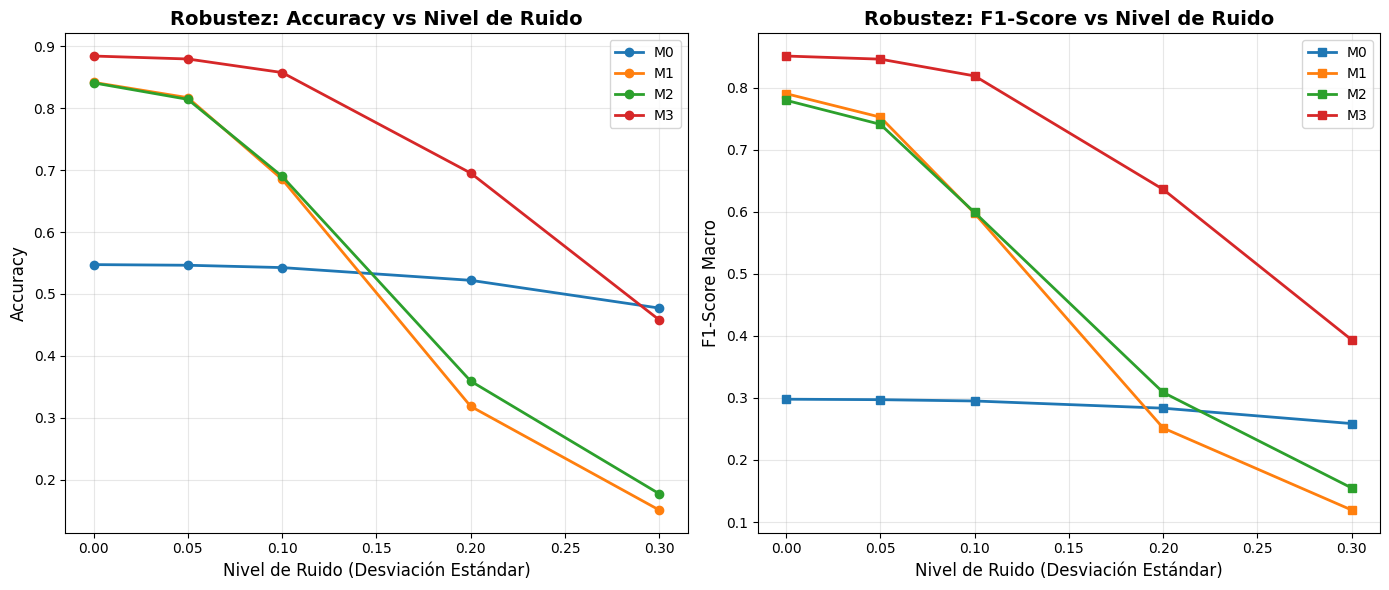


M0:
  Accuracy sin ruido:       0.5473
  Accuracy con ruido 0.30:  0.4771
  Degradación:              12.83%

M1:
  Accuracy sin ruido:       0.8418
  Accuracy con ruido 0.30:  0.1508
  Degradación:              82.09%

M2:
  Accuracy sin ruido:       0.8410
  Accuracy con ruido 0.30:  0.1771
  Degradación:              78.95%

M3:
  Accuracy sin ruido:       0.8844
  Accuracy con ruido 0.30:  0.4580
  Degradación:              48.21%
MODELO MÁS ROBUSTO AL RUIDO: M0


In [21]:
models_to_test = {
    'M0': (M0, 'numpy'),
    'M1': (M1, 'numpy'),
    'M2': (M2, 'pytorch'),
    'M3': (M3, 'pytorch')
}

noise_levels = [0.05, 0.10, 0.20, 0.30]

robustness_results = []
X_test_T_clean = X_test.T
X_test_pt_clean = X_test_pt

for model_name, (model, impl_type) in models_to_test.items():
    if impl_type == 'numpy':
        clean_metrics = report_performance(model, X_test_T_clean, y_test, NUM_CLASSES)
    else:  #pytorch
        clean_metrics = evaluate_pytorch_model(model, X_test_pt_clean, y_test_pt, NUM_CLASSES, DEVICE)
        
    robustness_results.append({
        'Modelo': model_name,
        'Nivel de Ruido (std)': 0.0,
        'Accuracy': clean_metrics['Accuracy'],
        'F1-Score Macro': clean_metrics['F1-Score Macro']
    })

    print(f"\nEvaluando robustez de {model_name}...")
    
    for std in noise_levels:
        X_test_noisy_np = add_gaussian_noise_numpy(X_test, std)
        if impl_type == 'numpy':
            X_test_noisy_T = X_test_noisy_np.T
            metrics = report_performance(model, X_test_noisy_T, y_test, NUM_CLASSES)
        else:  # pytorch
            X_test_noisy_pt = torch.from_numpy(X_test_noisy_np).float()
            metrics = evaluate_pytorch_model(model, X_test_noisy_pt, y_test_pt, NUM_CLASSES, DEVICE)
            
        robustness_results.append({
            'Modelo': model_name,
            'Nivel de Ruido (std)': std,
            'Accuracy': metrics['Accuracy'],
            'F1-Score Macro': metrics['F1-Score Macro']
        })

robustness_df = pd.DataFrame(robustness_results)

display(robustness_df)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for model_name in models_to_test.keys():
    model_data = robustness_df[robustness_df['Modelo'] == model_name]
    plt.plot(model_data['Nivel de Ruido (std)'], model_data['Accuracy'], 
             marker='o', label=model_name, linewidth=2)

plt.xlabel('Nivel de Ruido (Desviación Estándar)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Robustez: Accuracy vs Nivel de Ruido', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for model_name in models_to_test.keys():
    model_data = robustness_df[robustness_df['Modelo'] == model_name]
    plt.plot(model_data['Nivel de Ruido (std)'], model_data['F1-Score Macro'], 
             marker='s', label=model_name, linewidth=2)

plt.xlabel('Nivel de Ruido (Desviación Estándar)', fontsize=12)
plt.ylabel('F1-Score Macro', fontsize=12)
plt.title('Robustez: F1-Score vs Nivel de Ruido', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


for model_name in models_to_test.keys():
    model_data = robustness_df[robustness_df['Modelo'] == model_name]
    clean_acc = model_data[model_data['Nivel de Ruido (std)'] == 0.0]['Accuracy'].values[0]
    noisy_acc = model_data[model_data['Nivel de Ruido (std)'] == 0.30]['Accuracy'].values[0]
    degradation = (clean_acc - noisy_acc) / clean_acc * 100
    
    print(f"\n{model_name}:")
    print(f"  Accuracy sin ruido:       {clean_acc:.4f}")
    print(f"  Accuracy con ruido 0.30:  {noisy_acc:.4f}")
    print(f"  Degradación:              {degradation:.2f}%")

max_noise_data = robustness_df[robustness_df['Nivel de Ruido (std)'] == 0.30]
most_robust_idx = max_noise_data['Accuracy'].idxmax()
most_robust_model = max_noise_data.loc[most_robust_idx, 'Modelo']

print(f"MODELO MÁS ROBUSTO AL RUIDO: {most_robust_model}")